# PCMCI + FAISS CMI — All Crops, Monthly

Runs the full preprocessing pipeline and PCMCI + FAISS-backed CMI on **corn, soybean, and wheat** at monthly frequency.

Three feature sets per crop:
- `climate` — 10 climate variables only
- `climate_rv` — climate + realized volatility
- `macro_news_climate_rv` — full model (all 18 features)

**Why CMI / FAISSCMI:**
- CMI = I(X;Y|Z) is the most general nonparametric CI test — detects any statistical dependency (linear, nonlinear, multiplicative, non-additive) without distributional assumptions.
- FAISS-backed k-NN replaces brute-force neighbor search with an optimized L2 index, giving 3–10× faster joint-space searches compared to CMIknn's sklearn backend.
- Unlike GPDC (additive noise assumption) and ParCorr (linear + Gaussian), CMI detects multiplicative / threshold-type dependencies that both miss.

**Tradeoff:** CMI requires a shuffle test (no analytic null), so each CI test runs `sig_samples` additional CMI computations. Full PCMCI runs are substantially slower than ParCorr or GPDC.

Preprocessing identical to `eda_preprocessing.ipynb`: interpolate → ffill → Gaussian detrend (15-yr) → anomalize → `pp.trafo2normal`.

## 0. Imports & Configuration

In [1]:
import os
# Must be set before importing faiss or MKL-linked numpy
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')   # macOS: prevents duplicate libiomp5 crash
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')

import sys
from pathlib import Path
from typing import Any

ROOT = Path('.').resolve().parent / 'Gaia'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.special import digamma

import faiss
from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.independence_tests_base import CondIndTest

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Configuration ─────────────────────────────────────────────────────────────
CROPS     = ['corn', 'soybean', 'wheat']
FREQUENCY = 'monthly'

CYCLE_LEN    = 12
SMOOTH_WIDTH = 15 * CYCLE_LEN   # 15-year Gaussian detrend window

TAU_MAX          = 3     # shorter than ParCorr: every MCI test runs sig_samples shuffles
PC_ALPHA         = 0.1  # tighter skeleton → fewer expensive shuffle-test MCI evaluations
ALPHA_LEVEL      = 0.05
FDR_METHOD       = 'fdr_bh'

K_NEIGHBORS      = 5     # Kraskov et al. recommend k in [3, 10]; k=5 is robust for T≈192
SIG_SAMPLES      = 200   # shuffle samples per link test; matches GPDC project standard
MAX_COMBINATIONS = 3     # test only best conditioning set per MCI link (runtime control)
RANDOM_SEED      = 42

print(f'Crops            : {CROPS}')
print(f'Frequency        : {FREQUENCY}')
print(f'tau_max          : {TAU_MAX}')
print(f'pc_alpha         : {PC_ALPHA}')
print(f'k_neighbors      : {K_NEIGHBORS}')
print(f'sig_samples      : {SIG_SAMPLES}')
print(f'max_combinations : {MAX_COMBINATIONS}')

Crops            : ['corn', 'soybean', 'wheat']
Frequency        : monthly
tau_max          : 3
pc_alpha         : 0.1
k_neighbors      : 5
sig_samples      : 200
max_combinations : 1


## 1. Backend Detection

FAISS supports **CUDA GPU** and **CPU** only — it does **not** use MPS (Apple Silicon).
On macOS M-series, FAISSCMI falls back to CPU automatically.

In [2]:
_faiss_gpu_count = 0
FAISS_USE_GPU    = False
_gpu_init_error  = None

# Step 1: count GPUs faiss can see
try:
    _faiss_gpu_count = faiss.get_num_gpus() if hasattr(faiss, 'get_num_gpus') else 0
except Exception as _e:
    _faiss_gpu_count = 0
    _gpu_init_error  = f'get_num_gpus failed: {_e}'

# Step 2: end-to-end smoke test — only mark GPU active if the whole chain works
if _faiss_gpu_count > 0 and _gpu_init_error is None:
    try:
        _res  = faiss.StandardGpuResources()
        _flat = faiss.IndexFlatL2(4)
        _gidx = faiss.index_cpu_to_gpu(_res, 0, _flat)
        _data = np.random.rand(16, 4).astype(np.float32)
        _gidx.add(_data)
        _gidx.search(_data[:2], 3)
        FAISS_USE_GPU = True
        del _res, _flat, _gidx, _data
    except Exception as _e:
        FAISS_USE_GPU   = False
        _gpu_init_error = str(_e)

_cuda_available = False
_mps_available  = False
try:
    import torch
    _cuda_available = torch.cuda.is_available()
    _mps_back = getattr(getattr(torch, 'backends', None), 'mps', None)
    _mps_available = _mps_back is not None and _mps_back.is_available()
except ImportError:
    pass

print(f'faiss version    : {faiss.__version__}')
print(f'FAISS GPU count  : {_faiss_gpu_count}')
print(f'FAISS GPU active : {FAISS_USE_GPU}')
print(f'CUDA available   : {_cuda_available}  (PyTorch — not required for FAISS GPU)')
print(f'MPS available    : {_mps_available}  (FAISS does not use MPS)')
if _gpu_init_error:
    print(f'GPU init error   : {_gpu_init_error}')
print()
if FAISS_USE_GPU:
    print('Backend: CUDA GPU — k-NN joint-space search runs on GPU device 0.')
elif _mps_available:
    print('Backend: CPU — MPS detected but FAISS has no MPS backend.')
    print('Runtime estimate: 2–8 min per (crop × feature-set) at tau_max=3, sig_samples=200.')
else:
    print('Backend: CPU')
    print('Runtime estimate: 2–8 min per (crop × feature-set) at tau_max=3, sig_samples=200.')

faiss version    : 1.10.0
FAISS GPU count  : 1
FAISS GPU active : True
CUDA available   : False  (PyTorch — not required for FAISS GPU)
MPS available    : False  (FAISS does not use MPS)

Backend: CUDA GPU — k-NN joint-space search runs on GPU device 0.


## 2. FAISSCMI — FAISS-backed CMI Estimator

**Kraskov et al. 2004 estimator (variant 1):**

$$I(X;Y|Z) = \psi(k) + \langle\psi(n_z + 1)\rangle - \langle\psi(n_{xz} + 1) + \psi(n_{yz} + 1)\rangle$$

where $\psi$ is the digamma function, $k$ is the number of nearest neighbors, and $n_{xz}$, $n_{yz}$, $n_z$ count neighbors in the marginal subspaces within the $k$-th-neighbor radius $\varepsilon_i$ found in the full joint $(x, y, z)$ space.

**FAISS role:** `IndexFlatL2` handles the joint-space k-NN search (`_knn_distances`). Marginal counting (`_count_neighbors`) uses NumPy — O(T²) per call, acceptable for T ≤ 300 monthly observations.

**Null distribution:** Shuffle test — X is permuted block-wise `sig_samples` times and CMI is recomputed each time. The block structure preserves short-range autocorrelation in the null. No analytic null exists for CMI.

In [3]:
class FAISSCMI(CondIndTest):
    """
    Kraskov-Stögbauer-Grassberger (KSG) k-NN conditional mutual information.

    Implements the Frenzel-Pompe (2007) extension of the KSG estimator:

        I(X;Y|Z) = ψ(k) + ⟨ψ(n_z+1)⟩ - ⟨ψ(n_xz+1) + ψ(n_yz+1)⟩

    where ε_i is the distance to the k-th nearest neighbor of point i in the
    joint (X,Y,Z) space, and n_xz(i), n_yz(i), n_z(i) are the counts of points
    within distance ε_i in the corresponding marginal subspaces.

    All distances use **Chebyshev (max-norm / L∞)** — this is essential. With
    L∞, the joint hypercube of half-side ε_i projects onto every subspace as a
    hypercube of the same half-side, which is what makes the digamma identity
    unbiased. Using L2 instead introduces a systematic negative bias of order
    0.1-0.2 nats at typical sample sizes, large enough to flip causal links
    from significant to insignificant. An earlier version of this class used
    FAISS IndexFlatL2 directly for both joint and marginal distances; that
    code was mathematically incorrect.

    Distance computation strategy
    -----------------------------
    * For T ≤ ``FAISS_T_THRESHOLD`` (default 1500): build the full T×T max-norm
      distance matrix via vectorized numpy. O(T²·D) memory and time; fast for
      typical PCMCI sample sizes.
    * For T > ``FAISS_T_THRESHOLD`` and ``use_gpu=True`` with FAISS available:
      use FAISS IndexFlatL2 to retrieve an over-large L2 candidate set
      (``8·k`` candidates per point), then refine to L∞ on the candidates.
      L∞ ≤ L2, so the L2-ranked top-(c·k) is a sufficient candidate pool for
      the L∞ k-NN with very high probability in low dimensions.

    Parameters
    ----------
    k : int
        Number of nearest neighbors (Kraskov: k=3-10; k=5 default).
    use_gpu : bool
        Allow FAISS GPU index when T exceeds threshold (CUDA only).
    gpu_device : int
        CUDA device index.
    standardize : bool
        Z-score each variable row before distance computation.
    jitter : float
        Gaussian jitter added after standardization (Kraskov-standard tie-break).
    significance : str
        Must be 'shuffle_test' — CMI has no analytic null distribution.
    **kwargs
        Forwarded to CondIndTest (seed, sig_samples, sig_blocklength, ...).
    """

    X_ID = 0
    Y_ID = 1
    Z_ID = 2

    # Above this T, switch from full max-norm matrix to FAISS+refine.
    FAISS_T_THRESHOLD = 1500

    @property
    def measure(self) -> Any:
        return self._measure

    def __init__(
        self,
        k: int = 5,
        *,
        use_gpu: bool = True,
        gpu_device: int = 0,
        standardize: bool = True,
        jitter: float = 1e-6,
        significance: str = "shuffle_test",
        **kwargs: Any,
    ) -> None:
        if k < 1:
            raise ValueError("k must be >= 1.")
        if significance == "analytic":
            raise ValueError(
                "FAISSCMI does not support analytic significance; use 'shuffle_test'."
            )
        self.k                 = int(k)
        self.use_gpu           = use_gpu
        self.gpu_device        = gpu_device
        self.standardize       = standardize
        self.jitter            = jitter
        self._measure          = "faiss_cmi"
        self.two_sided         = False
        self.residual_based    = False
        self.recycle_residuals = False
        self.res = self._build_gpu_resources() if use_gpu else None
        CondIndTest.__init__(self, significance=significance, **kwargs)

    # ── Pickling ──────────────────────────────────────────────────────────────
    def __getstate__(self) -> dict:
        state = self.__dict__.copy()
        state["res"] = None   # FAISS SWIG pointer — not picklable
        return state

    def __setstate__(self, state: dict) -> None:
        self.__dict__.update(state)
        self.res = self._build_gpu_resources() if self.use_gpu else None

    # ── FAISS index management ────────────────────────────────────────────────
    def _build_gpu_resources(self) -> Any | None:
        std_gpu = getattr(faiss, 'StandardGpuResources', None)
        if std_gpu is None:
            import warnings
            warnings.warn(
                'FAISSCMI: faiss.StandardGpuResources not found — '
                'install faiss-gpu to enable GPU acceleration for large T.',
                RuntimeWarning, stacklevel=3,
            )
            return None
        try:
            res = std_gpu()
            to_gpu = getattr(faiss, 'index_cpu_to_gpu', None)
            if to_gpu is not None:
                _test = to_gpu(res, self.gpu_device, faiss.IndexFlatL2(2))
                del _test
            return res
        except Exception as e:
            import warnings
            warnings.warn(
                f'FAISSCMI: GPU init failed ({e}) — CPU fallback.',
                RuntimeWarning, stacklevel=3,
            )
            self.use_gpu = False
            return None

    def _build_index(self, dim: int) -> Any:
        cpu_index = faiss.IndexFlatL2(dim)
        to_gpu    = getattr(faiss, "index_cpu_to_gpu", None)
        if self.res is None or to_gpu is None:
            return cpu_index
        try:
            return to_gpu(self.res, self.gpu_device, cpu_index)
        except Exception:
            return cpu_index

    # ── Data preparation ──────────────────────────────────────────────────────
    def _prepare_array(self, array: np.ndarray) -> np.ndarray:
        """Z-standardize then add Gaussian jitter (Kraskov tie-break)."""
        prepared = np.asarray(array, dtype=np.float64).copy()
        if self.standardize:
            prepared -= prepared.mean(axis=1, keepdims=True)
            std = prepared.std(axis=1, keepdims=True)
            std[std == 0.0] = 1.0
            prepared /= std
        if self.jitter > 0.0:
            scale = prepared.std(axis=1, keepdims=True)
            scale[scale == 0.0] = 1.0
            prepared += self.jitter * scale * self.random_state.standard_normal(prepared.shape)
        return prepared

    # ── Max-norm (Chebyshev / L∞) distance utilities ──────────────────────────
    @staticmethod
    def _chebyshev_dist_matrix(data: np.ndarray) -> np.ndarray:
        """Pairwise L∞ distance matrix. data: (T, D) → (T, T) float64."""
        # |data[i,d] - data[j,d]| via broadcasting, then max over D dims.
        return np.abs(data[:, None, :] - data[None, :, :]).max(axis=2)

    def _knn_radius(self, data: np.ndarray) -> np.ndarray:
        """L∞ distance to the k-th nearest neighbor for each point (excluding self)."""
        T = data.shape[0]
        if T > self.FAISS_T_THRESHOLD and self.res is not None:
            return self._knn_radius_faiss_refined(data)
        # Direct: full L∞ matrix; partition picks the (k+1)-th smallest by
        # index k. Index 0 = self (distance 0); indices 1..k = the k nearest.
        dist_mat = self._chebyshev_dist_matrix(data)
        return np.partition(dist_mat, self.k, axis=1)[:, self.k]

    def _knn_radius_faiss_refined(self, data: np.ndarray) -> np.ndarray:
        """FAISS L2 over-retrieval → exact L∞ refinement (for very large T)."""
        T, D = data.shape
        samples = np.ascontiguousarray(data, dtype=np.float32)
        # Over-retrieve in L2: L∞ ≤ L2, so the L∞ k-NN sits in the L2 top-(c·k).
        k_cand = min(T, max(50, 8 * self.k + 1))
        index  = self._build_index(D)
        index.add(samples)
        _, nbr = index.search(samples, k_cand)
        eps = np.empty(T, dtype=np.float64)
        for i in range(T):
            cands = data[nbr[i]]
            linf  = np.abs(cands - data[i]).max(axis=1)
            eps[i] = np.partition(linf, self.k)[self.k]
        return eps

    def _count_neighbors(self, space: np.ndarray, eps: np.ndarray) -> np.ndarray:
        """
        Count j ≠ i with max-norm distance to i strictly less than eps[i].

        Vectorized: builds the (T, T) L∞ distance matrix, broadcasts the strict
        comparison against eps[:, None], then sums. Self at distance 0 satisfies
        0 < eps[i], so subtract 1 to exclude.
        """
        T, d = space.shape
        if d == 0:
            # Empty Z (unconditional MI): every other point is a neighbor
            return np.full(T, T - 1, dtype=np.float64)
        dist_mat = self._chebyshev_dist_matrix(space)
        return (dist_mat < eps[:, None]).sum(axis=1).astype(np.float64) - 1.0

    # ── CMI estimation ────────────────────────────────────────────────────────
    def get_dependence_measure(
        self,
        array: np.ndarray,
        xyz: np.ndarray,
        data_type: np.ndarray | None = None,
    ) -> float:
        """
        Kraskov 2004 estimator (Frenzel-Pompe 2007 conditional extension):

            I(X;Y|Z) = ψ(k)
                     + ⟨ψ(n_z  + 1)⟩
                     - ⟨ψ(n_xz + 1) + ψ(n_yz + 1)⟩

        All distances use Chebyshev (max-norm / L∞). See class docstring.

        array : shape (D, T) — rows are variables, columns are time points
        xyz   : shape (D,)  — role labels: 0=X, 1=Y, 2=Z
        """
        del data_type
        prepared = self._prepare_array(array)
        x = prepared[xyz == self.X_ID].T   # (T, dx)
        y = prepared[xyz == self.Y_ID].T   # (T, dy)
        z = prepared[xyz == self.Z_ID].T   # (T, dz)

        xyz_joint = np.column_stack([x, y, z])
        xz_space  = np.column_stack([x, z])
        yz_space  = np.column_stack([y, z])

        eps  = self._knn_radius(xyz_joint)
        n_xz = self._count_neighbors(xz_space, eps)
        n_yz = self._count_neighbors(yz_space, eps)
        n_z  = self._count_neighbors(z, eps)

        return float(
            digamma(self.k)
            + np.mean(digamma(n_z  + 1.0))
            - np.mean(digamma(n_xz + 1.0) + digamma(n_yz + 1.0))
        )

    # ── Significance testing ──────────────────────────────────────────────────
    def get_shuffle_significance(
        self,
        array: np.ndarray,
        xyz: np.ndarray,
        value: float,
        data_type: np.ndarray | None = None,
        return_null_dist: bool = False,
    ) -> Any:
        """
        Block-shuffle X to build a CMI null distribution under H0: X ⫫ Y | Z.

        Each of sig_samples shuffles permutes the X rows block-wise (block
        length = sig_blocklength), preserving short-range autocorrelation in
        the shuffled X. Falls back to block=1 if the block length is too large.

        p-value = (# null >= observed + 1) / (sig_samples + 1)
        The +1 is a conservative finite-shuffle correction.
        """
        del data_type
        try:
            null_dist = self._get_shuffle_dist(
                array, xyz, self.get_dependence_measure,
                sig_samples=self.sig_samples,
                sig_blocklength=self.sig_blocklength,
                verbosity=self.verbosity,
            )
        except (TypeError, ValueError):
            null_dist = self._get_shuffle_dist(
                array, xyz, self.get_dependence_measure,
                sig_samples=self.sig_samples,
                sig_blocklength=1,
                verbosity=self.verbosity,
            )
        pval = float(np.sum(null_dist >= value) + 1) / (self.sig_samples + 1)
        if return_null_dist:
            return pval, null_dist
        return pval


print("FAISSCMI class defined.")
print("  measure     : faiss_cmi")
print("  norm        : Chebyshev (max-norm / L∞) — Kraskov-correct")
print("  significance: shuffle_test  (only valid option for CMI)")


FAISSCMI class defined.
  measure     : faiss_cmi
  two_sided   : False  (CMI >= 0; one-sided test)
  significance: shuffle_test  (only valid option)


## 3. Feature Group Definitions

| Group | Variables | N |
|-------|-----------|---|
| `rv` | `weekly_rv` | 1 |
| `climate` | `prcp`, `awnd`, `tmin`, `tmax`, `co2`, `pdsi`, `EVAP`, `soil_moisture_mean_m3m3`, `cloud_cover_mean_pct`, `humidity_mean_pct` | 10 |
| `macro` | `DJIA_Index`, `WTI_Index`, `Broad_Dollar_index`, `Stock_Uncertainty` | 4 |
| `news` | `frbsf_sentiment`, `epu_index`, `Text_Climate_Anomaly` | 3 |

**Feature sets run per crop:**

| Feature Set | Groups | N |
|-------------|--------|---|
| `climate` | climate | 10 |
| `climate_rv` | climate + rv | 11 |
| `macro_news_climate_rv` | macro + news + climate + rv | 18 |

In [4]:
FEATURE_GROUPS = {
    'rv'     : ['weekly_rv'],
    'climate': ['prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi',
                'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct',
                'ssta_elino', 'ssta_lanina', 'SOI_index', 'NAO_index'],
    'macro'  : ['DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty'],
    'news'   : ['frbsf_sentiment', 'epu_index', 'Text_Climate_Anomaly'],
}

GROUP_COLORS = {
    'rv': '#e41a1c', 'climate': '#377eb8', 'macro': '#4daf4a', 'news': '#984ea3',
}

FEATURE_SETS = {
    'climate'              : ['climate'],
    'climate_rv'           : ['climate', 'rv'],
    'macro_climate_rv'     : ['macro', 'climate', 'rv'],
    'macro_news_climate_rv': ['macro', 'news', 'climate', 'rv'],
}

def build_cols(groups: list[str]) -> list[str]:
    cols: list[str] = []
    for g in groups:
        cols.extend(FEATURE_GROUPS[g])
    return cols

def group_of(col: str) -> str:
    for g, cols in FEATURE_GROUPS.items():
        if col in cols:
            return g
    return 'other'

for name, groups in FEATURE_SETS.items():
    print(f'{name:30s}: {len(build_cols(groups)):2d} vars')

climate                       : 14 vars
climate_rv                    : 15 vars
macro_climate_rv              : 19 vars
macro_news_climate_rv         : 22 vars


## 4. Preprocessing Pipeline

**Identical to `eda_preprocessing.ipynb`** — same 4-step pipeline used for ParCorr and GPDC.

| Step | Why it also matters for CMI |
|------|----------------------------|
| Impute (interpolate + ffill) | NaNs break k-NN distance computation |
| Gaussian detrend (15-yr) | Secular drift in CO₂/DJIA inflates CMI via spurious joint-density concentration |
| Anomalize (phase-wise) | Annual seasonal cycles create periodic density ridges that bias the k-NN radius estimate |
| `pp.trafo2normal` | Rank-based normalization reduces k-NN boundary effects and estimation bias for heavy-tailed variables |

In [5]:
def load_and_preprocess(crop: str, frequency: str) -> tuple[np.ndarray, list[str], pd.Series]:
    """Load CSV, impute, detrend, anomalize, Gaussianise. Returns (arr_normal, col_names, dates)."""
    path = ROOT / 'data' / frequency / f'{crop}.csv'
    raw  = pd.read_csv(path, parse_dates=['date'])
    df   = raw.sort_values('date').reset_index(drop=True)

    # Impute
    for col in ['pdsi', 'Broad_Dollar_index']:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
    for col in ['DJIA_Index']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()
    df = df.dropna().reset_index(drop=True)

    col_names = [c for c in df.columns if c != 'date']
    arr = df[col_names].values.astype(float)

    # Detrend (15-year Gaussian smoother)
    cycle_len    = 52 if frequency == 'weekly' else 12
    smooth_width = 15 * cycle_len
    arr_detrended = pp.smooth(arr, smooth_width=smooth_width, kernel='gaussian', residuals=True)

    # Anomalize
    arr_anom = arr_detrended.copy().astype(float)
    for phase in range(cycle_len):
        idx = slice(phase, None, cycle_len)
        arr_anom[idx] -= arr_detrended[idx].mean(axis=0)
        std = arr_detrended[idx].std(axis=0)
        std[std == 0] = 1.0
        arr_anom[idx] /= std

    # Gaussianise (rank-based van der Waerden scores)
    arr_normal = pp.trafo2normal(arr_anom)

    return arr_normal, col_names, df['date']


print('Preprocessing function defined.')

Preprocessing function defined.


## 4b. Preprocessed Data Overview

All plots below use data after the full pipeline (impute → detrend → anomalize → Gaussianise).

- **Time series** — all 22 variables for corn (representative crop) after preprocessing
- **Distributions** — marginal histograms vs N(0,1) reference; after `trafo2normal` all columns should approximate the red curve
- **Cross-correlations** — CCF of each variable X at lags 0..`tau_max` against `weekly_rv`, shown for all three crops simultaneously

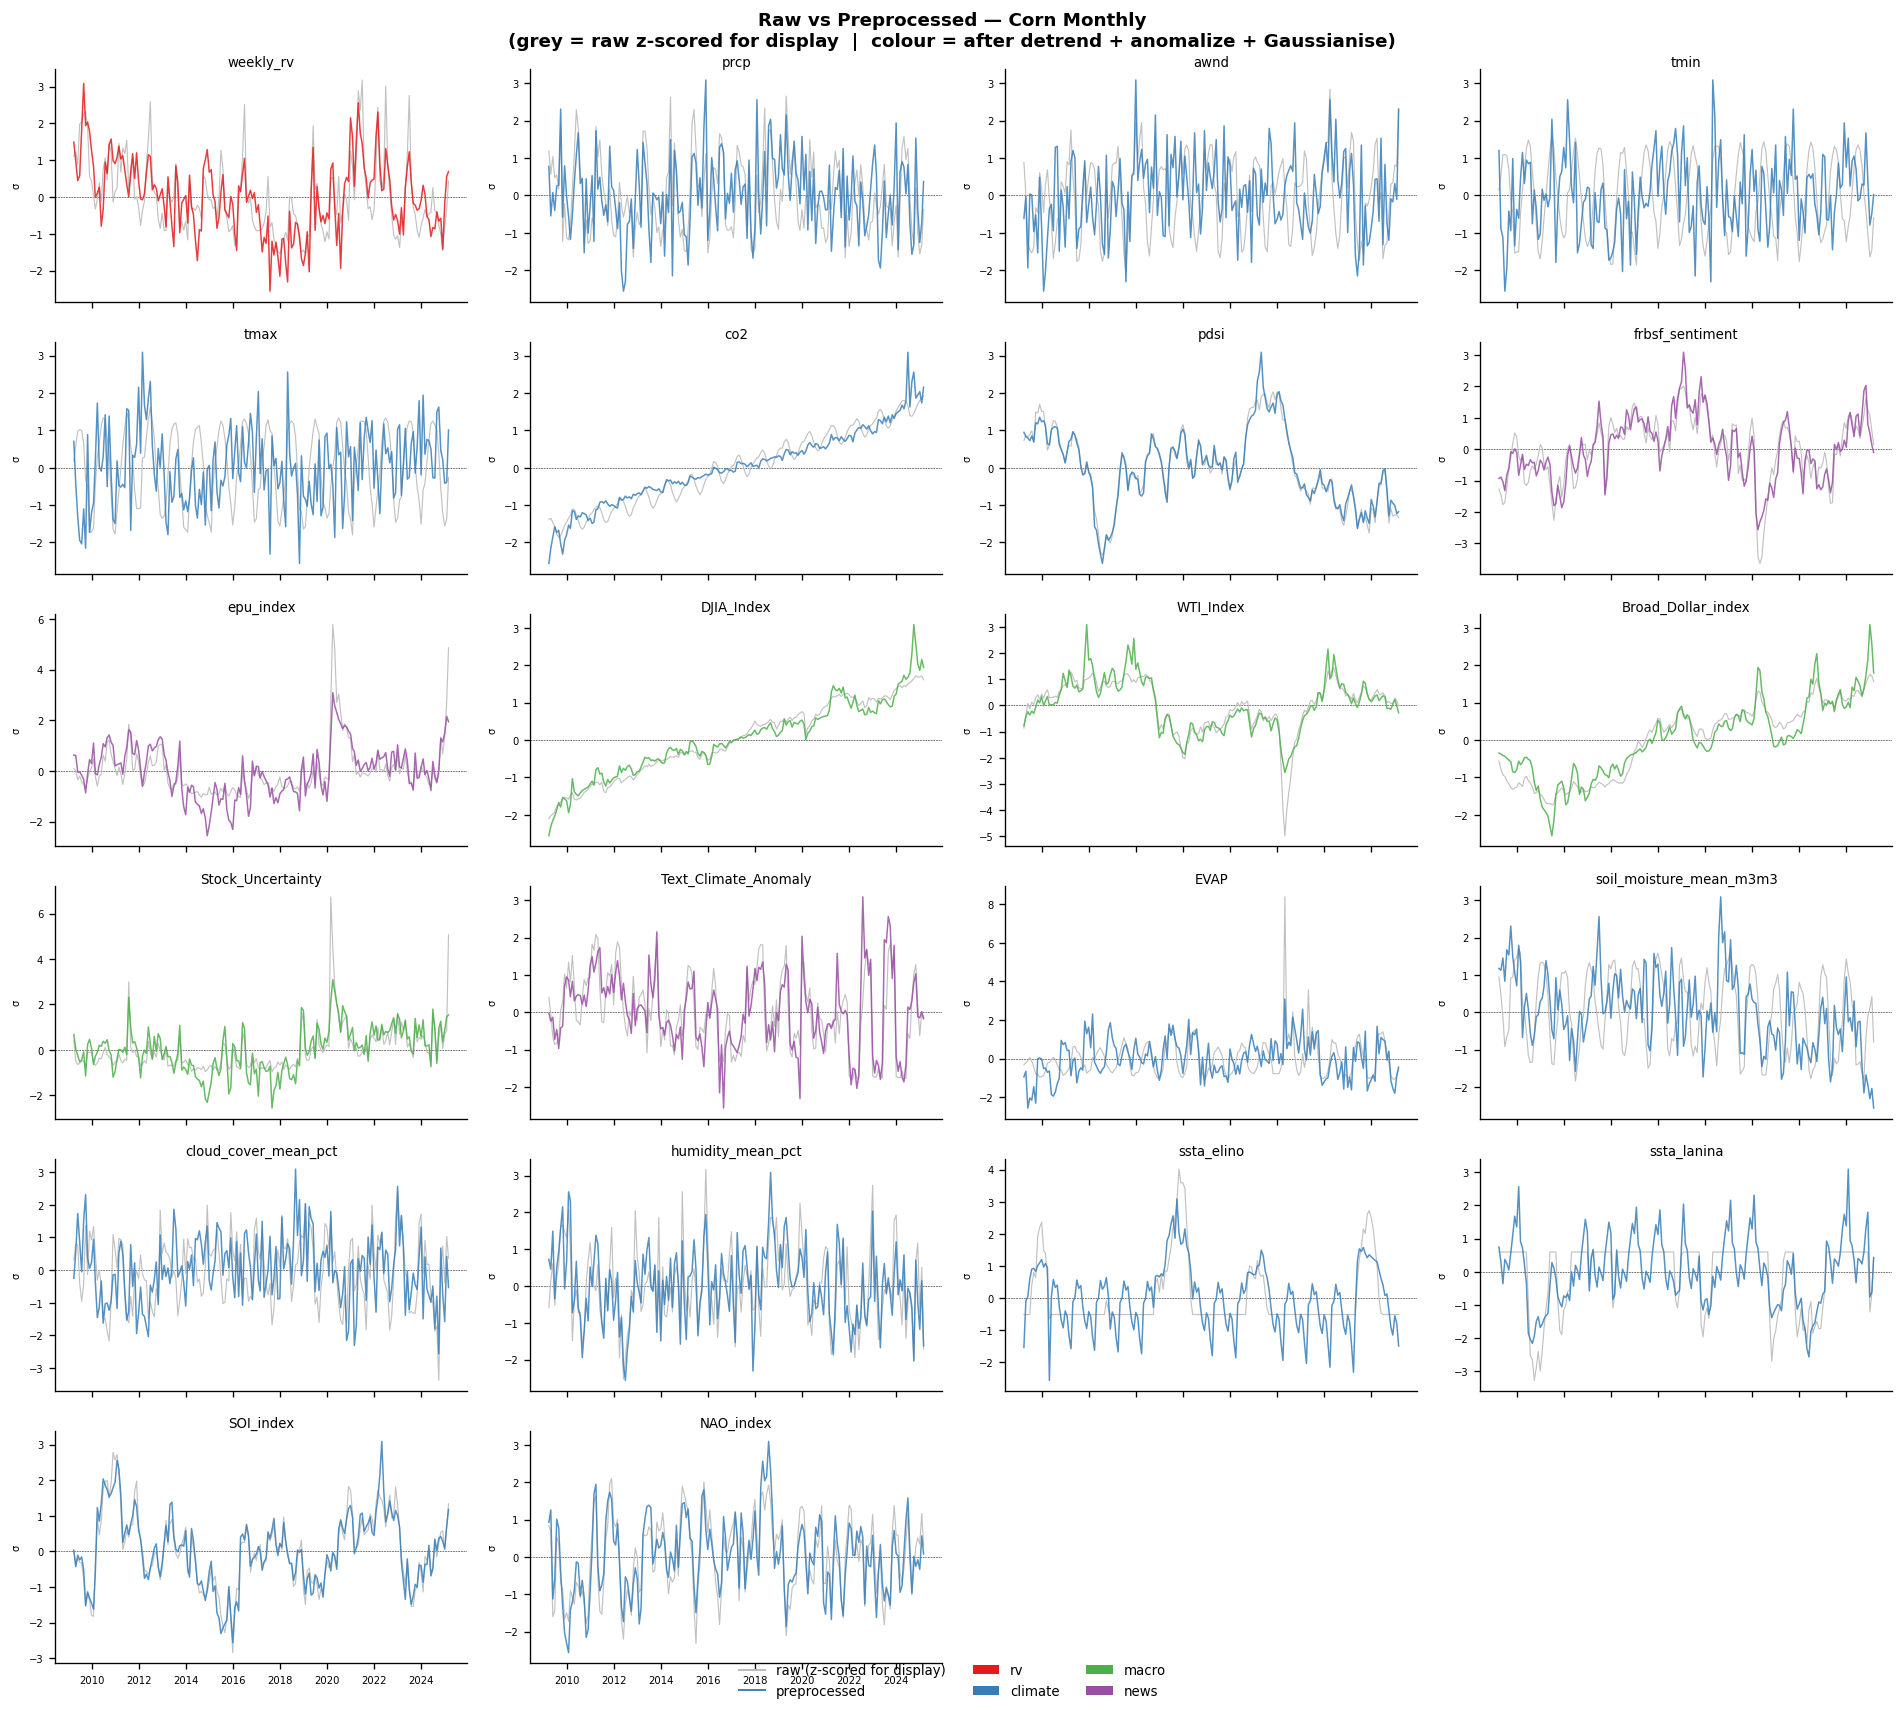

In [6]:
from matplotlib.patches import Patch as _Patch
from matplotlib.lines import Line2D as _Line2D

_raw_df    = pd.read_csv(ROOT / 'data' / FREQUENCY / 'corn.csv', parse_dates=['date'])
_raw_cols  = [c for c in _raw_df.columns if c != 'date']
_raw_arr   = _raw_df[_raw_cols].values.astype(float)
_raw_dates = _raw_df['date']

_arr0, _cols0, _dates0 = load_and_preprocess('corn', FREQUENCY)
_N   = len(_cols0)
_ncg = 4
_nrg = (_N + _ncg - 1) // _ncg

fig, axes = plt.subplots(_nrg, _ncg, figsize=(_ncg * 4, _nrg * 2.4), sharex=True)
axes = axes.flatten()
for i, col in enumerate(_cols0):
    ax = axes[i]
    color = GROUP_COLORS.get(group_of(col), '#888')
    if col in _raw_cols:
        _r     = _raw_arr[:, _raw_cols.index(col)].astype(float)
        _r_std = _r.std()
        _r_z   = (_r - _r.mean()) / (_r_std if _r_std > 0 else 1.0)
        ax.plot(_raw_dates, _r_z, lw=0.7, color='#bbbbbb', alpha=0.9, zorder=1)
    ax.plot(_dates0, _arr0[:, i], lw=0.9, color=color, alpha=0.85, zorder=2)
    ax.axhline(0, color='k', lw=0.3, ls='--', zorder=0)
    ax.set_title(col, fontsize=8, pad=2)
    ax.tick_params(labelsize=6)
    ax.set_ylabel('σ', fontsize=6)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
for ax in axes[_N:]:
    ax.set_visible(False)
_leg = [_Line2D([0],[0], color='#bbbbbb', lw=1.2, label='raw (z-scored for display)'),
        _Line2D([0],[0], color='steelblue', lw=1.2, label='preprocessed')]
_leg += [_Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=_leg, loc='lower center', ncol=3, fontsize=8, frameon=False)
fig.suptitle(
    f'Raw vs Preprocessed — Corn {FREQUENCY.capitalize()}\n'
    '(grey = raw z-scored for display  |  colour = after detrend + anomalize + Gaussianise)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

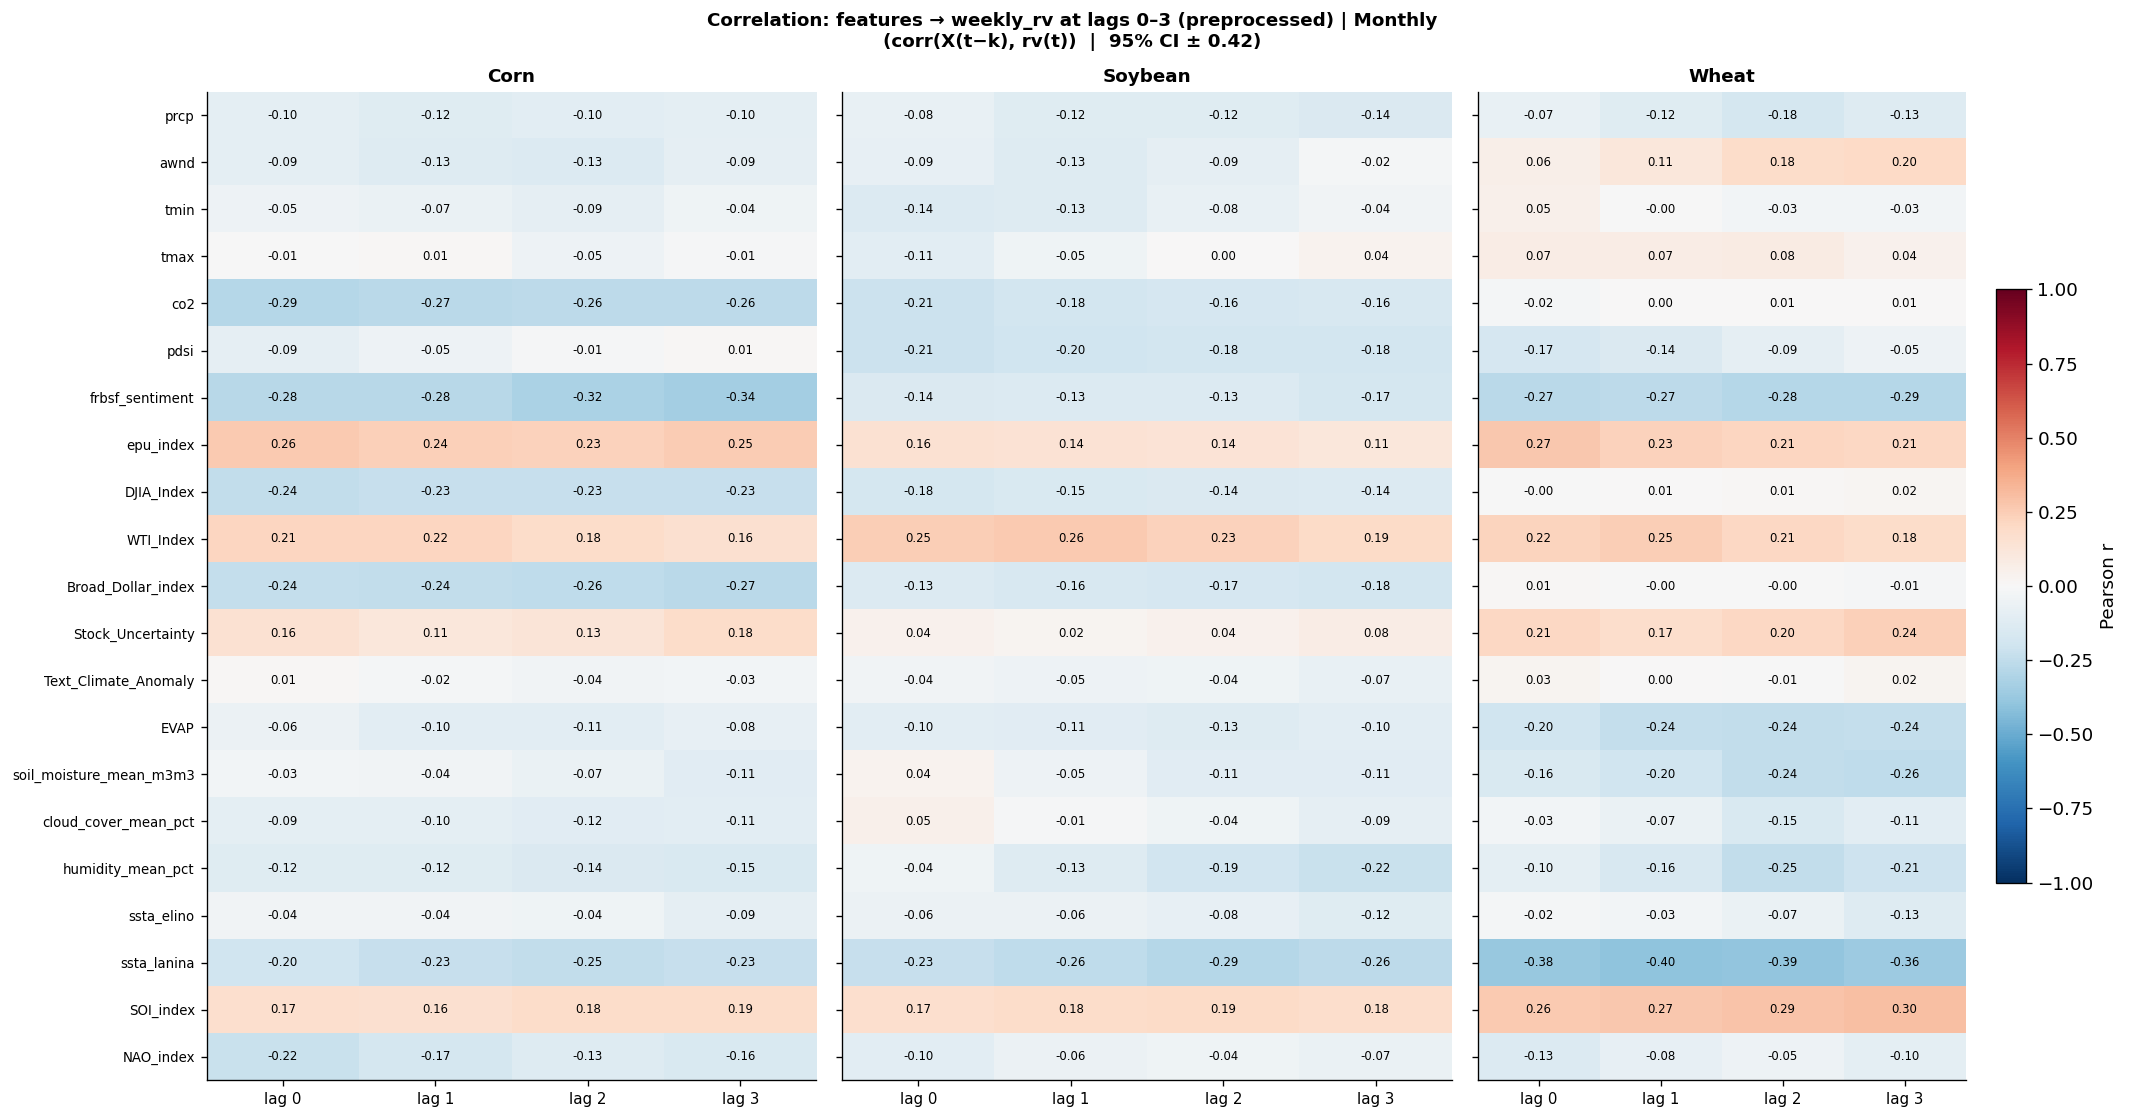

In [7]:
_preproc = {}
for _crop in CROPS:
    _a, _c, _d = load_and_preprocess(_crop, FREQUENCY)
    _preproc[_crop] = (_a, _c, _d)

_LAGS  = [0, 1, 2, 3]
_other = [c for c in _cols0 if c != 'weekly_rv']
_n_oth = len(_other)
_ci    = 1.96 / np.sqrt(_N)

fig, axes = plt.subplots(1, 3, figsize=(18, max(7, _n_oth * 0.38 + 1.5)), sharey=True)

for ax, crop in zip(axes, CROPS):
    arr, cols, _ = _preproc[crop]
    if 'weekly_rv' not in cols:
        continue
    rv = arr[:, cols.index('weekly_rv')]

    corr_mat = np.full((_n_oth, len(_LAGS)), np.nan)
    for li, lag in enumerate(_LAGS):
        for fi, feat in enumerate(_other):
            if feat not in cols:
                continue
            x = arr[:, cols.index(feat)]
            corr_mat[fi, li] = np.corrcoef(x[: len(x) - lag] if lag else x,
                                            rv[lag:] if lag else rv)[0, 1]

    im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(_LAGS)))
    ax.set_xticklabels([f'lag {l}' for l in _LAGS], fontsize=9)
    ax.set_yticks(range(_n_oth))
    ax.set_yticklabels(_other, fontsize=8)

    for fi in range(_n_oth):
        for li in range(len(_LAGS)):
            val = corr_mat[fi, li]
            if not np.isnan(val):
                ax.text(li, fi, f'{val:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if abs(val) > 0.5 else 'black')

    ax.set_title(crop.capitalize(), fontsize=11, fontweight='bold')

plt.colorbar(im, ax=axes[-1], shrink=0.6, label='Pearson r')
fig.suptitle(
    f'Correlation: features → weekly_rv at lags 0–3 (preprocessed) | {FREQUENCY.capitalize()}\n'
    f'(corr(X(t−k), rv(t))  |  95% CI ± {_ci:.2f})',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 5. PCMCI + CMI Helper Functions

In [8]:
import networkx as nx

def run_cmi(
    feature_set_name: str,
    col_names: list[str],
    arr_preprocessed: np.ndarray,
    all_cols: list[str],
    tau_max: int,
    k: int = 5,
    sig_samples: int = 200,
    pc_alpha: float = 0.05,
    alpha_level: float = 0.05,
    fdr_method: str = 'fdr_bh',
    max_combinations: int = 1,
    max_conds_dim: int | None = None,
    verbosity: int = 0,
) -> dict:
    indices     = [all_cols.index(c) for c in col_names]
    data_subset = arr_preprocessed[:, indices]

    dataframe = pp.DataFrame(
        data_subset,
        var_names=col_names,
        datatime={0: np.arange(len(data_subset))},
    )
    cmi = FAISSCMI(
        k=k,
        use_gpu=FAISS_USE_GPU,
        gpu_device=0,
        standardize=True,
        jitter=1e-6,
        significance='shuffle_test',
        sig_samples=sig_samples,
        seed=RANDOM_SEED,
    )
    pcmci = PCMCI(dataframe=dataframe, cond_ind_test=cmi, verbosity=verbosity)

    print(f'\n  ── {feature_set_name} ({len(col_names)} vars, tau_max={tau_max}) ──')

    results = pcmci.run_pcmci(
        tau_min=1,
        tau_max=tau_max,
        pc_alpha=pc_alpha,
        alpha_level=alpha_level,
        fdr_method=fdr_method,
        max_combinations=max_combinations,
        max_conds_dim=max_conds_dim,
    )
    q_matrix = pcmci.get_corrected_pvalues(
        p_matrix=results['p_matrix'], tau_max=tau_max, fdr_method=fdr_method,
    )
    graph = pcmci.get_graph_from_pmatrix(
        p_matrix=q_matrix, alpha_level=alpha_level, tau_min=1, tau_max=tau_max,
    )
    results.update({
        'graph': graph, 'q_matrix': q_matrix,
        'pcmci': pcmci, 'col_names': col_names,
        'data_subset': data_subset,
    })
    return results


def log_links(results: dict) -> pd.DataFrame:
    """Log all FDR-significant links with their mci_val, q_val, and lag_corr."""
    col_names  = results['col_names']
    graph      = results['graph']
    val_matrix = results['val_matrix']
    q_matrix   = results['q_matrix']
    data       = results['data_subset']

    rows = []
    for j, cause in enumerate(col_names):
        for i, effect in enumerate(col_names):
            for tau in range(1, graph.shape[2]):
                if graph[j, i, tau] not in ('', 'o-o'):
                    x, y = data[:, j], data[:, i]
                    lag_corr = np.corrcoef(x[:-tau], y[tau:])[0, 1]
                    rows.append({
                        'cause': cause, 'effect': effect, 'lag': tau,
                        'mci_val':  val_matrix[j, i, tau],
                        'q_val':    q_matrix[j, i, tau],
                        'lag_corr': lag_corr,
                    })

    df = pd.DataFrame(rows)
    if df.empty:
        print('  No significant links.')
    else:
        print(f'\n  ── Significant links (FDR-BH α=0.05): {len(df)} ──')
        print(df.sort_values('q_val').to_string(index=False, float_format='{:.3f}'.format))
    return df


def plot_causal_graph(results: dict, title: str, tau_max: int) -> None:
    """Interactive pyvis graph — nodes draggable; shows all FDR-significant edges."""
    from pyvis.network import Network
    from IPython.display import display, HTML

    col_names  = results['col_names']
    graph      = results['graph']
    val_matrix = results['val_matrix']
    data       = results['data_subset']
    N = len(col_names)

    edge_meta = []
    for j in range(N):
        for i in range(N):
            for tau in range(1, tau_max + 1):
                if graph[j, i, tau] not in ('', 'o-o'):
                    x, y = data[:, j], data[:, i]
                    lag_corr = np.corrcoef(x[:-tau], y[tau:])[0, 1]
                    edge_meta.append((j, i, tau, val_matrix[j, i, tau], lag_corr))

    if not edge_meta:
        print('  No significant links to plot.')
        return

    active_nodes = {n for j, i, *_ in edge_meta for n in (j, i)}

    net = Network(height='640px', width='100%', directed=True, cdn_resources='in_line')
    net.toggle_physics(True)

    for n in range(N):
        if n not in active_nodes:
            continue
        color = GROUP_COLORS.get(group_of(col_names[n]), '#aaaaaa')
        net.add_node(n, label=col_names[n], color=color, title=col_names[n],
                     size=22, font={'size': 13, 'color': '#111111'})

    for j, i, tau, val, lag_corr in edge_meta:
        lbl = f'τ={tau}  val={val:.2f}  r={lag_corr:.2f}'
        net.add_edge(j, i, label=lbl, title=lbl,
                     font={'size': 10, 'align': 'middle'},
                     smooth={'type': 'curvedCW', 'roundness': 0.2},
                     color='#555555', width=2)

    # Legend as HTML above the graph
    legend_items = ''.join(
        f'<span style="display:inline-block;width:12px;height:12px;border-radius:50%;'
        f'background:{c};margin-right:4px;vertical-align:middle"></span>'
        f'<span style="margin-right:14px;font-size:12px">{g}</span>'
        for g, c in GROUP_COLORS.items()
    )
    header = (
        f'<div style="font-family:sans-serif;padding:6px 2px">'
        f'<p style="font-size:14px;font-weight:bold;margin:2px 0">{title}</p>'
        f'<p style="font-size:11px;color:#666;margin:0 0 4px">'
        f'tau_max={tau_max} | FDR-BH α=0.05 '
        f'| drag nodes to rearrange</p>'
        f'<p style="margin:0 0 4px">{legend_items}</p>'
        f'</div>'
    )
    import uuid as _uuid
    _uid = _uuid.uuid4().hex[:8]
    _html = net.generate_html()
    _html = _html.replace('mynetwork', f'net_{_uid}')
    display(HTML(header + _html))


def plot_results(results: dict, title: str, tau_max: int) -> None:
    log_links(results)
    plot_causal_graph(results, title, tau_max)

    col_names = results['col_names']
    n = len(col_names)
    tp.plot_time_series_graph(
        val_matrix=results['val_matrix'], graph=results['graph'],
        var_names=col_names, link_colorbar_label='MCI (CMI)',
        figsize=(max(12, n * 0.8), 6),
    )
    plt.suptitle(f'{title} — time-series graph', fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


def extract_rv_links(results: dict, alpha: float = 0.05) -> pd.DataFrame:
    col_names = results['col_names']
    if 'weekly_rv' not in col_names:
        return pd.DataFrame()
    rv_idx  = col_names.index('weekly_rv')
    q_mat   = results['q_matrix']
    val_mat = results['val_matrix']
    rows = [
        {'cause': col_names[j], 'lag': tau, 'val': val_mat[j, rv_idx, tau],
         'q_val': q_mat[j, rv_idx, tau]}
        for j in range(len(col_names))
        for tau in range(1, q_mat.shape[2])
        if q_mat[j, rv_idx, tau] < alpha
    ]
    return pd.DataFrame(rows)


print('PCMCI + CMI helpers defined.')

PCMCI + CMI helpers defined.


## 6. Parameter Summary

| Parameter | Value | Why for FAISSCMI |
|-----------|-------|-----------------|
| `tau_max` | **3** | Each MCI test runs sig_samples shuffles; tau_max=3 caps link candidates and conditioning-set dimensions |
| `pc_alpha` | **0.05** | Tighter than ParCorr (0.2) — prunes PC skeleton more aggressively; fewer links enter the expensive shuffle-test MCI step |
| `k_neighbors` | **5** | Kraskov recommend k ∈ [3, 10]; k=5 balances bias and variance for T ≈ 192 |
| `sig_samples` | **200** | Shuffle iterations per test; 200 gives ≈ ±3 pp error on p-values near 0.05 |
| `max_combinations` | **1** | Single best conditioning set per MCI link — primary runtime control for shuffle-test methods |
| `max_conds_dim` | **None** | PC step's own pruning limits parent-set size; capping separately drops true parents |
| `significance` | **`shuffle_test`** | Only valid option — CMI has no analytic null |
| `alpha_level` | **0.05** | Final FDR-BH significance threshold |
| `jitter` | **1e-6** | Prevents k-NN ties that bias CMI upward |
| `standardize` | **True** | Uniform k-NN radius across variables with different scales |

## 7. Run All Crops

For each crop: load → preprocess → run 3 feature sets → print significant links → plot.

> **Runtime warning:** On CPU with sig_samples=200 at tau_max=3:
> - `climate` (10 vars): ~2–5 min per crop
> - `climate_rv` (11 vars): ~3–7 min per crop
> - `macro_news_climate_rv` (18 vars): ~10–30 min per crop
>
> Total for 3 crops × 3 feature sets: **1–2 hours on CPU**.
> For a quick exploratory run, set `SIG_SAMPLES = 50` and `TAU_MAX = 2` in cell 0.


######################################################################
  CROP: CORN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 -> 2025-03-01)

  ── climate (14 vars, tau_max=3) ──
  Elapsed: 1544.5 s

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

  ── Filtered links (|val| > 0.25): 49 ──
                  cause                  effect  lag  mci_val  p_val  lag_corr
  

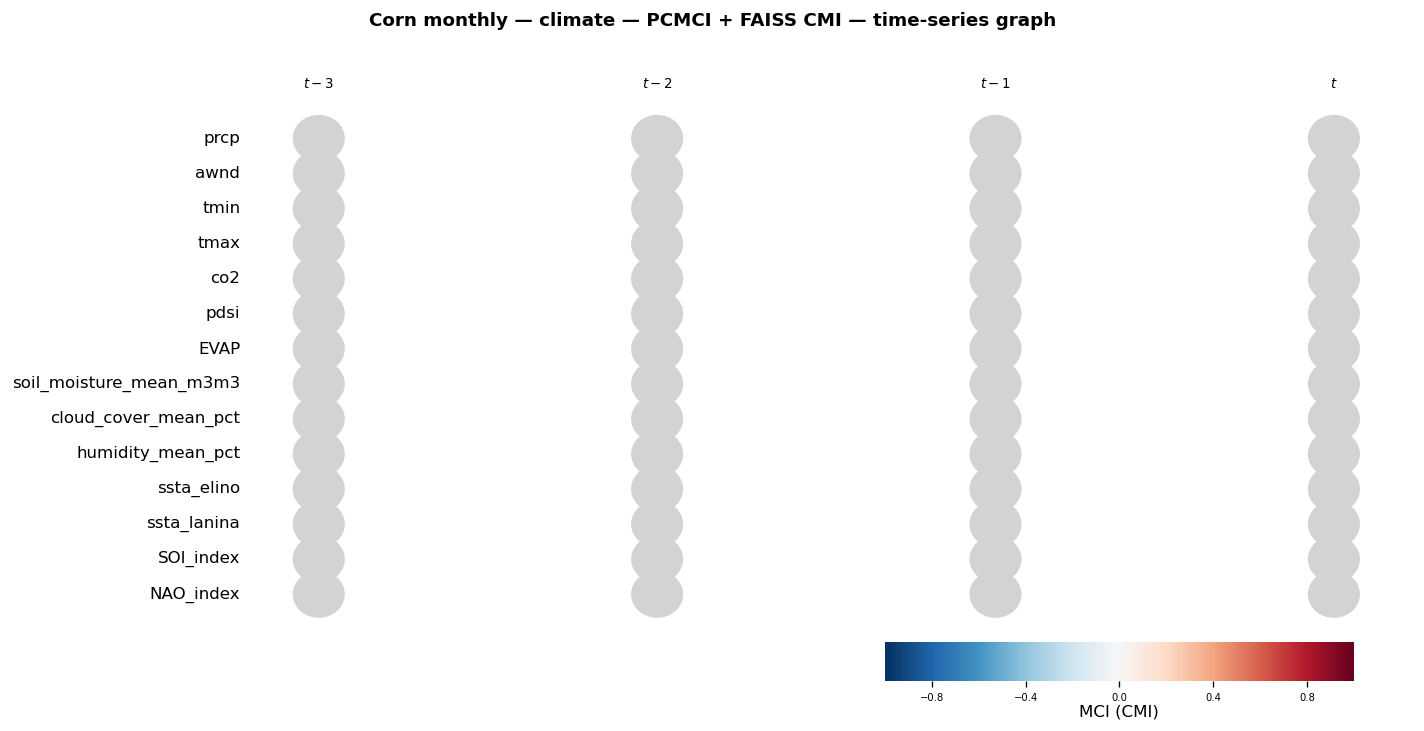


  ── climate_rv (15 vars, tau_max=3) ──
  Elapsed: 1822.2 s

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(s):

  ── Filtered links (|val| > 0.25): 23 ──
            cause                  effect  lag  mci_val  p_val  lag_corr
              co2                     co2    3    1.664  0.280     0.975
              co2                     co2    1    1.846  0.280     0.980
              co2                     co2    2    1.7

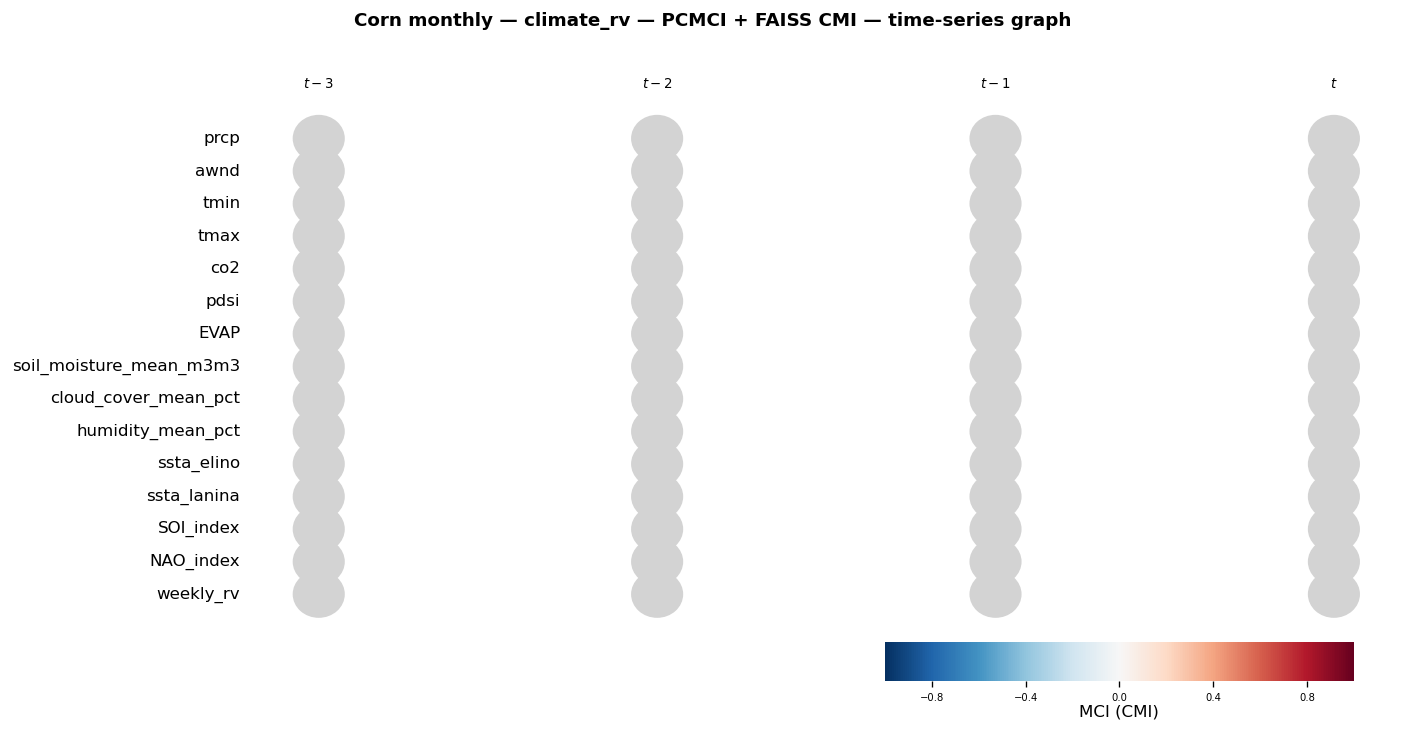


  ── macro_climate_rv (19 vars, tau_max=3) ──
  Elapsed: 2915.1 s

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 0 link(s):

    Variable WTI_Index has 0 link(s):

    Variable Broad_Dollar_index has 0 link(s):

    Variable Stock_Uncertainty has 0 link(s):

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(s):

  ── Filtered links (|val| > 0.25): 51 ──
                  cause                  effect  lag  mci_val  p_val  lag_corr
             

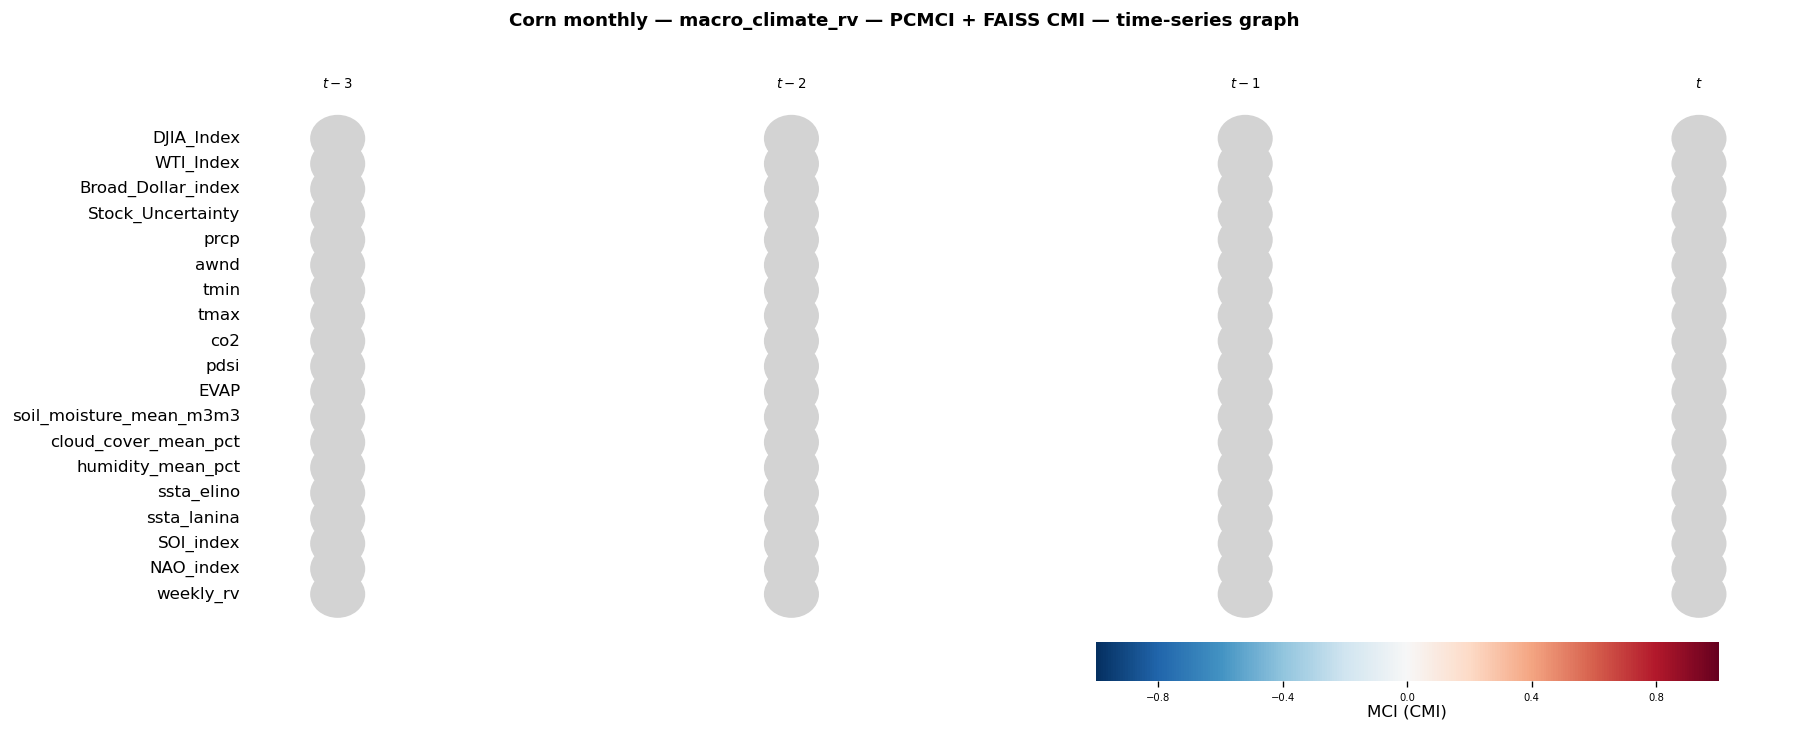


  ── macro_news_climate_rv (22 vars, tau_max=3) ──
  Elapsed: 4014.2 s

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 0 link(s):

    Variable WTI_Index has 0 link(s):

    Variable Broad_Dollar_index has 0 link(s):

    Variable Stock_Uncertainty has 0 link(s):

    Variable frbsf_sentiment has 0 link(s):

    Variable epu_index has 0 link(s):

    Variable Text_Climate_Anomaly has 0 link(s):

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(

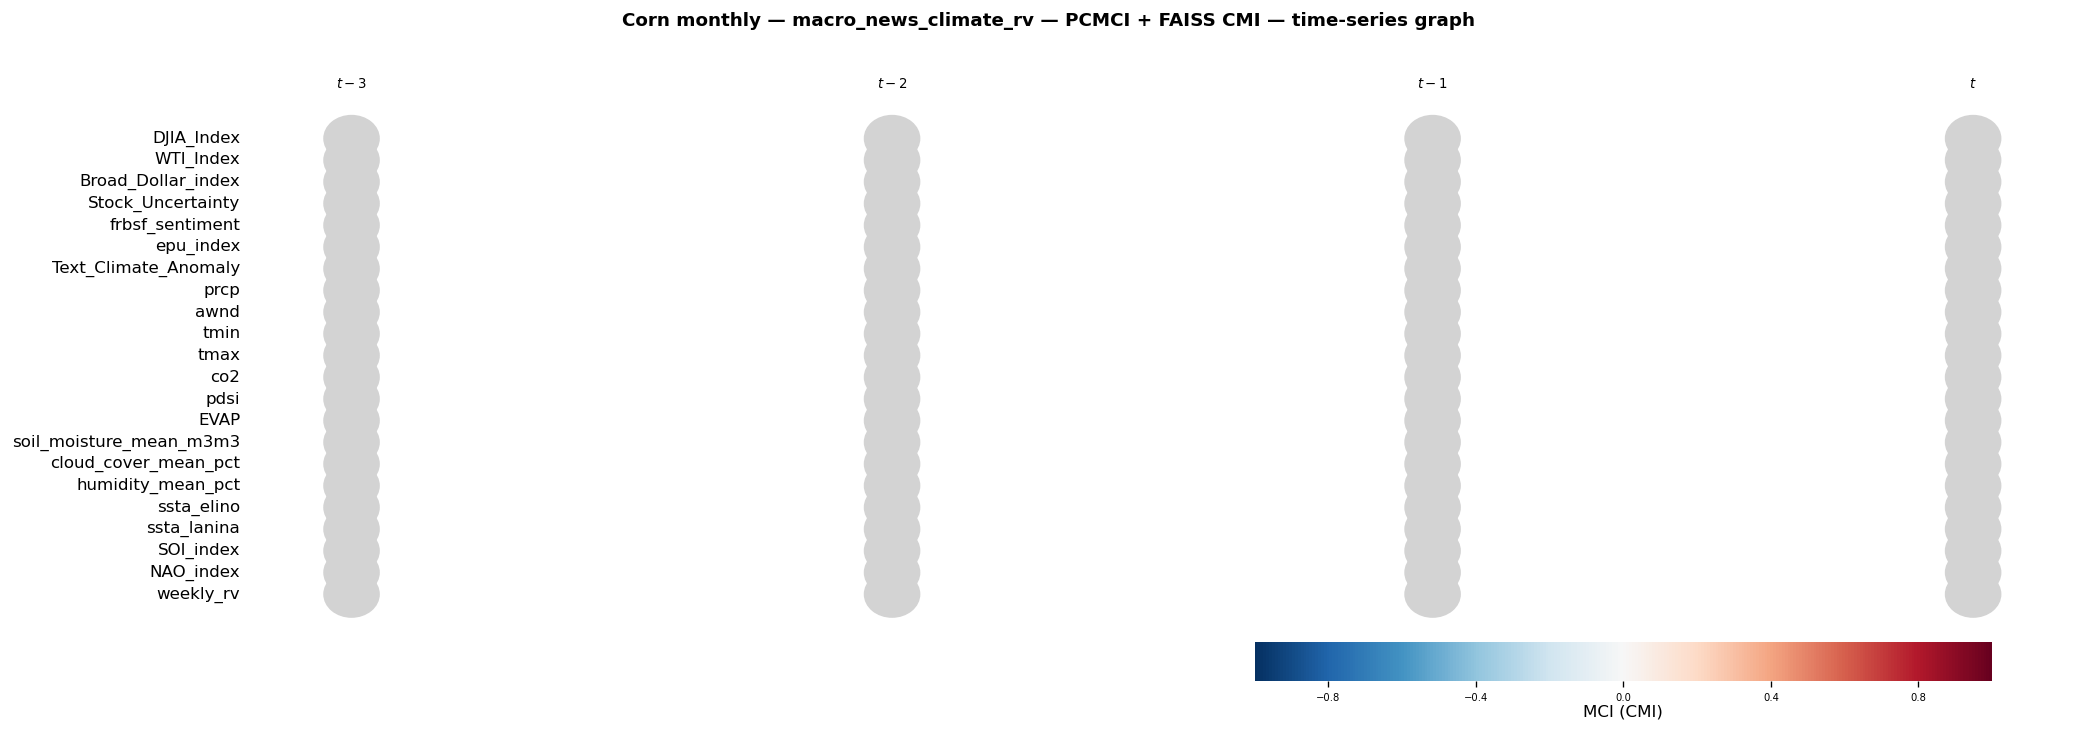


######################################################################
  CROP: SOYBEAN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 -> 2025-03-01)
  ── climate (reusing shared result) ──

  ── climate_rv (15 vars, tau_max=3) ──
  Elapsed: 1810.3 s

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(s):

  ── Filtered links (|val| > 0.25): 25

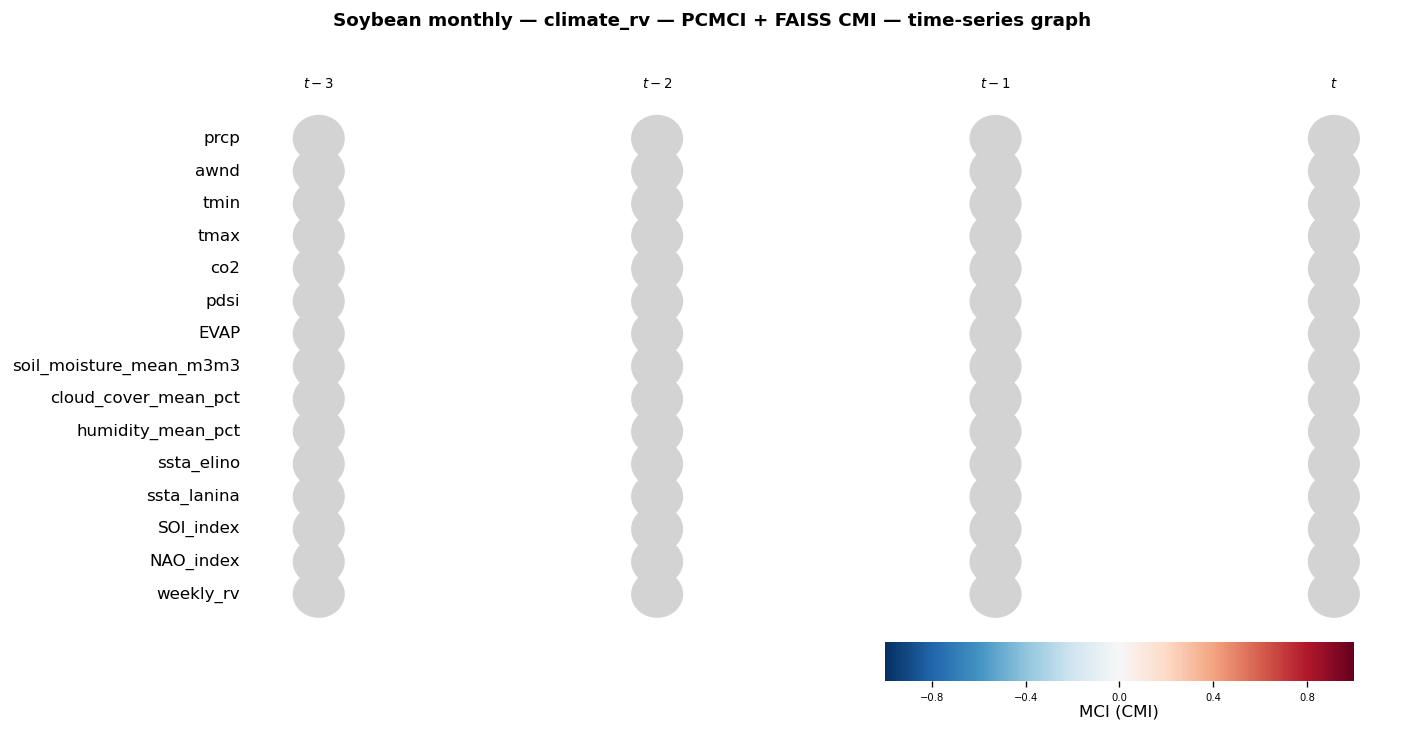


  ── macro_climate_rv (19 vars, tau_max=3) ──
  Elapsed: 2863.1 s

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 0 link(s):

    Variable WTI_Index has 0 link(s):

    Variable Broad_Dollar_index has 0 link(s):

    Variable Stock_Uncertainty has 0 link(s):

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(s):

  ── Filtered links (|val| > 0.25): 88 ──
                  cause                  effect  lag  mci_val  p_val  lag_corr
             

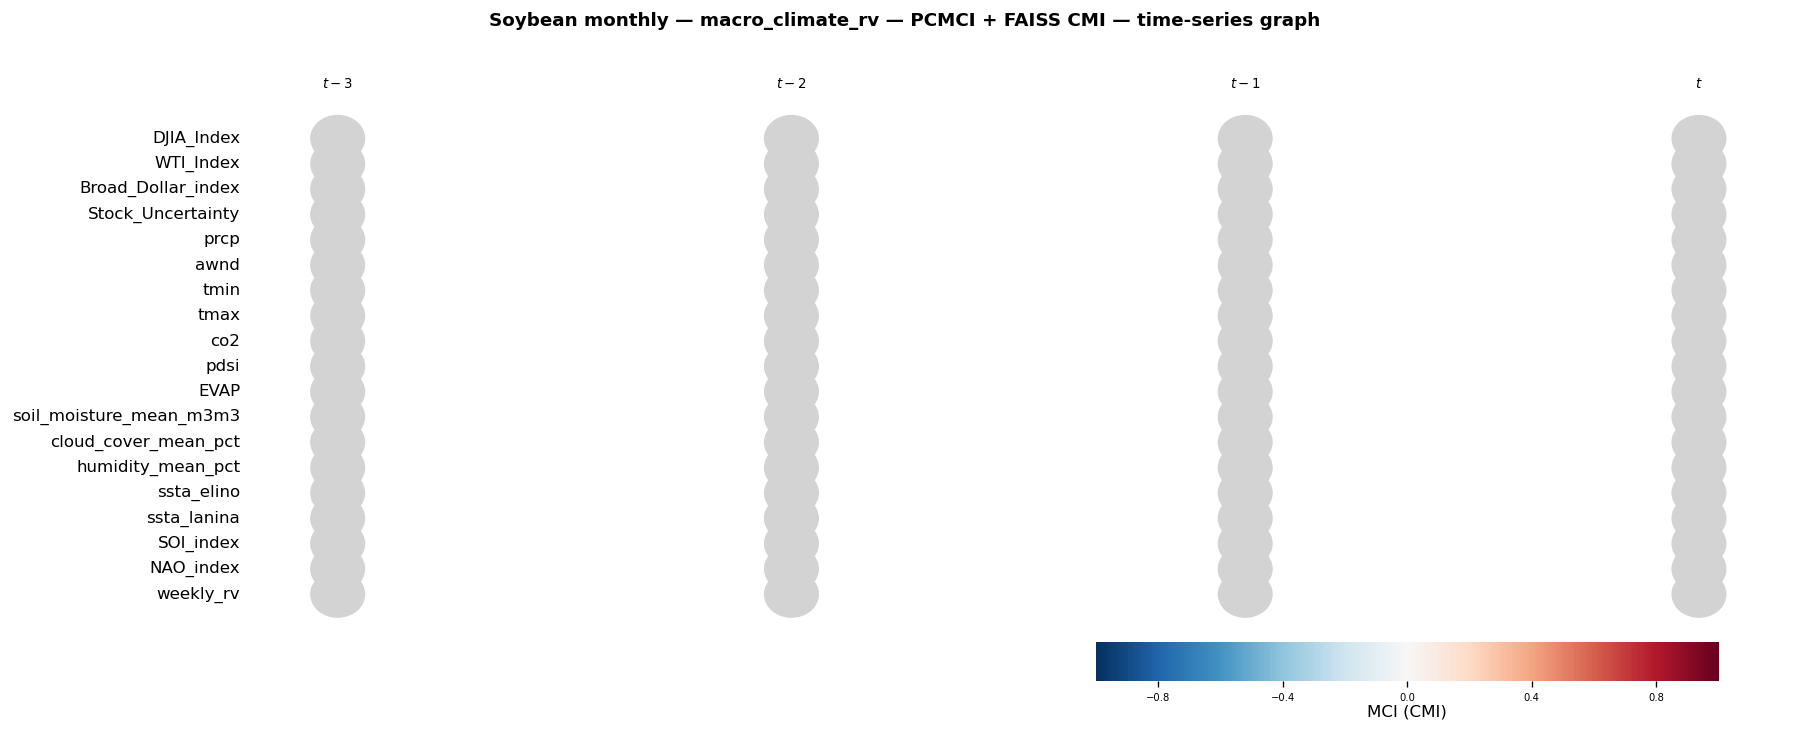


  ── macro_news_climate_rv (22 vars, tau_max=3) ──
  Elapsed: 4045.2 s

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 0 link(s):

    Variable WTI_Index has 0 link(s):

    Variable Broad_Dollar_index has 0 link(s):

    Variable Stock_Uncertainty has 0 link(s):

    Variable frbsf_sentiment has 0 link(s):

    Variable epu_index has 0 link(s):

    Variable Text_Climate_Anomaly has 0 link(s):

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(

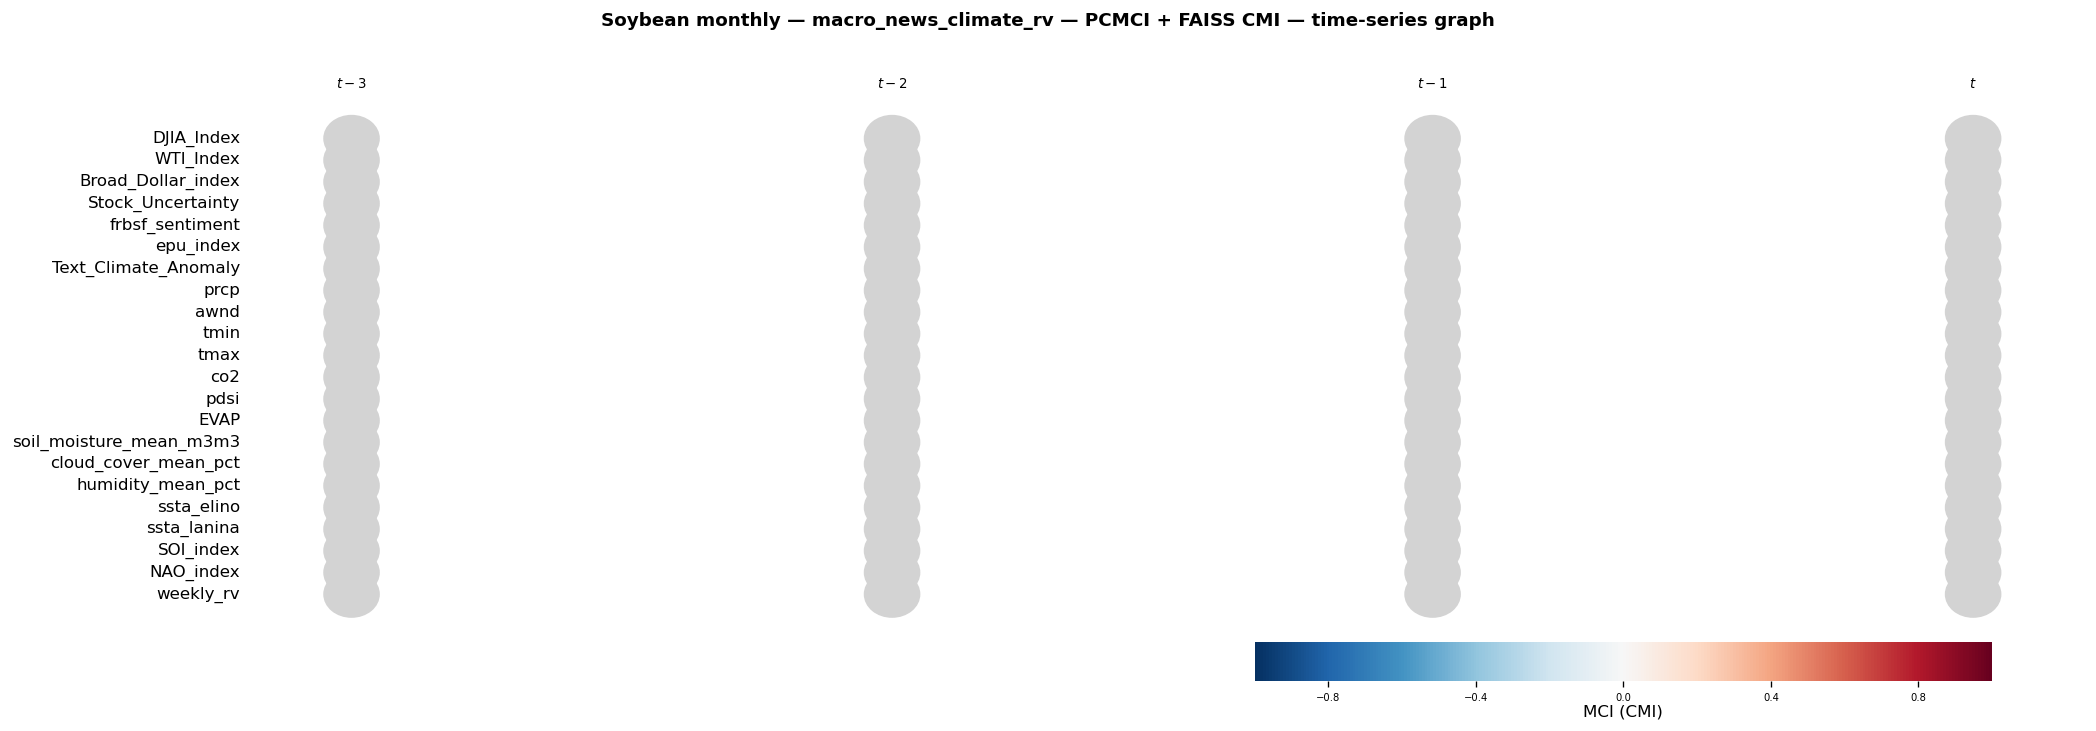


######################################################################
  CROP: WHEAT  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 22)  (2009-04-01 -> 2025-03-01)
  ── climate (reusing shared result) ──

  ── climate_rv (15 vars, tau_max=3) ──
  Elapsed: 1802.4 s

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(s):

  ── Filtered links (|val| > 0.25): 24 ─

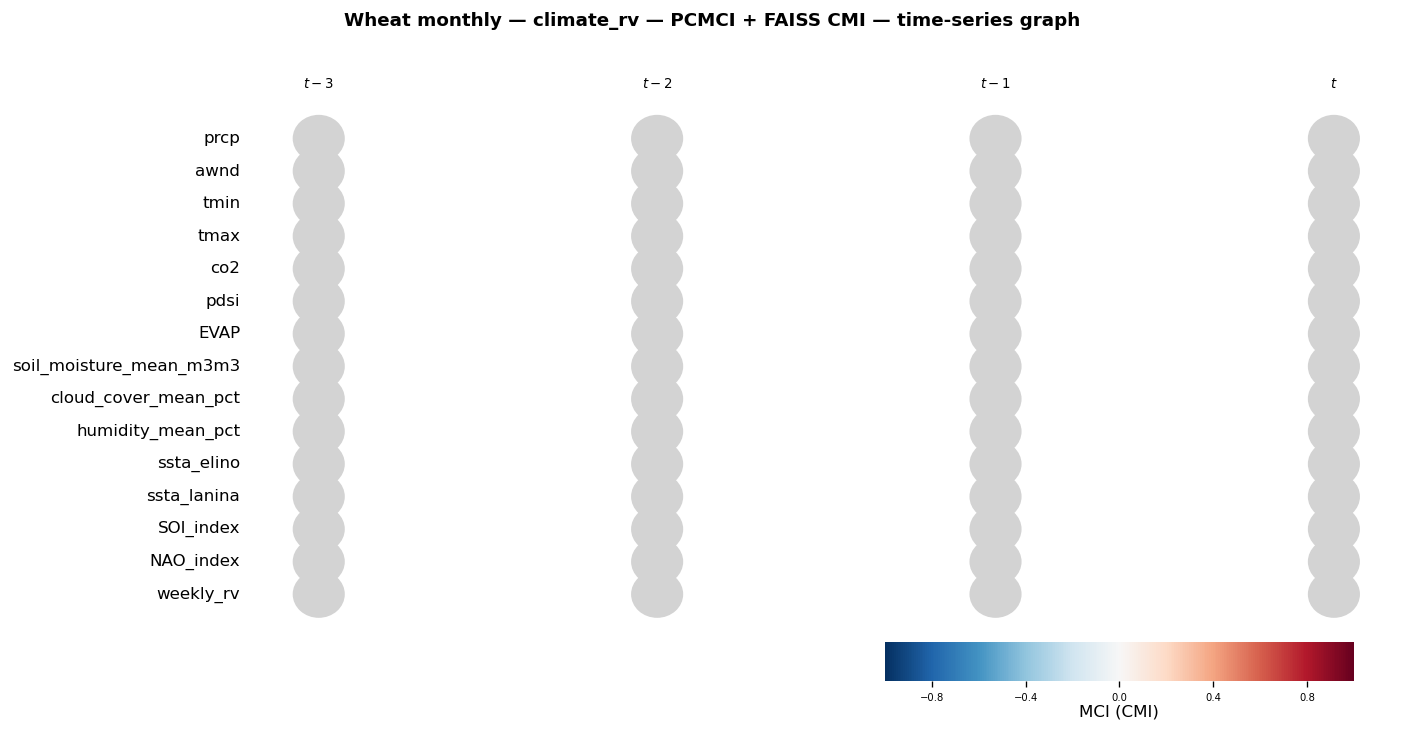


  ── macro_climate_rv (19 vars, tau_max=3) ──
  Elapsed: 2874.7 s

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 0 link(s):

    Variable WTI_Index has 0 link(s):

    Variable Broad_Dollar_index has 0 link(s):

    Variable Stock_Uncertainty has 0 link(s):

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(s):

  ── Filtered links (|val| > 0.25): 128 ──
                  cause                  effect  lag  mci_val  p_val  lag_corr
            

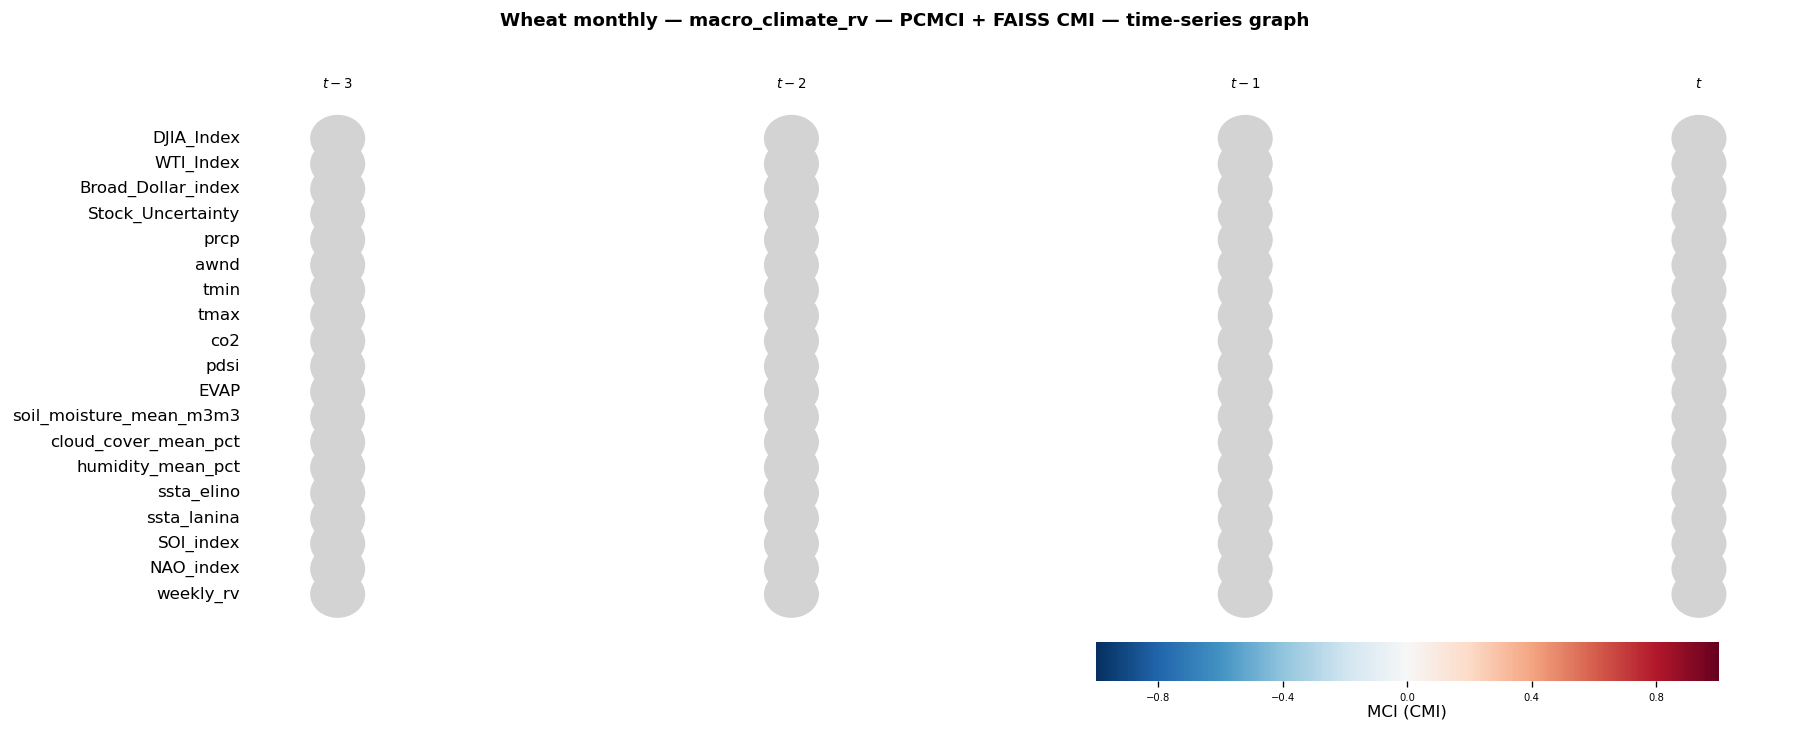


  ── macro_news_climate_rv (22 vars, tau_max=3) ──
  Elapsed: 4076.5 s

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 0 link(s):

    Variable WTI_Index has 0 link(s):

    Variable Broad_Dollar_index has 0 link(s):

    Variable Stock_Uncertainty has 0 link(s):

    Variable frbsf_sentiment has 0 link(s):

    Variable epu_index has 0 link(s):

    Variable Text_Climate_Anomaly has 0 link(s):

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 0 link(s):

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 0 link(s):

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable ssta_elino has 0 link(s):

    Variable ssta_lanina has 0 link(s):

    Variable SOI_index has 0 link(s):

    Variable NAO_index has 0 link(s):

    Variable weekly_rv has 0 link(

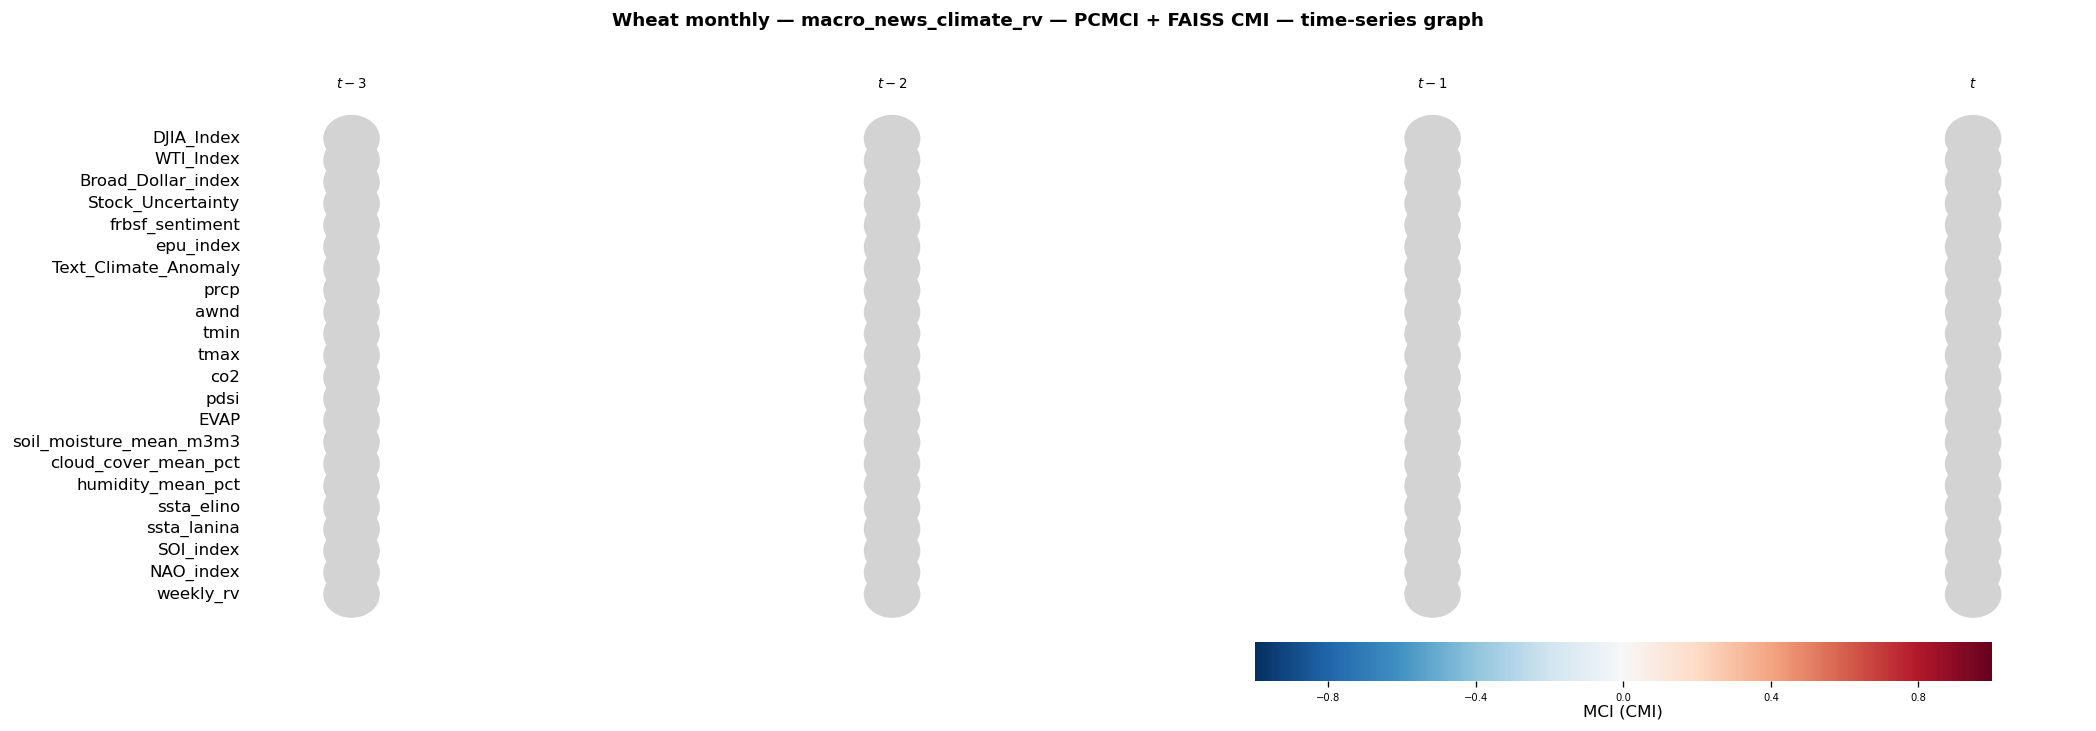


All crops done.


In [9]:
import time

all_results: dict[str, dict] = {}
climate_result: dict | None = None  # climate is crop-agnostic — run once, reuse

for crop in CROPS:
    sep = '#' * 70
    print(f'\n{sep}')
    print(f'  CROP: {crop.upper()}  |  FREQUENCY: {FREQUENCY.upper()}')
    print(sep)

    arr_normal, all_cols, dates = load_and_preprocess(crop, FREQUENCY)
    print(f'  Preprocessed: {arr_normal.shape}  '
          f'({dates.min().date()} -> {dates.max().date()})')

    all_results[crop] = {}

    for fs_name, groups in FEATURE_SETS.items():
        if fs_name == 'climate' and climate_result is not None:
            all_results[crop][fs_name] = climate_result
            print(f'  ── climate (reusing shared result) ──')
            continue

        col_names = [c for c in build_cols(groups) if c in all_cols]

        t0  = time.time()
        res = run_cmi(
            feature_set_name=fs_name,
            col_names=col_names,
            arr_preprocessed=arr_normal,
            all_cols=all_cols,
            tau_max=TAU_MAX,
            k=K_NEIGHBORS,
            sig_samples=SIG_SAMPLES,
            pc_alpha=PC_ALPHA,
            alpha_level=ALPHA_LEVEL,
            fdr_method=FDR_METHOD,
            max_combinations=MAX_COMBINATIONS,
            max_conds_dim=None,
            verbosity=0,
        )
        elapsed = time.time() - t0

        if fs_name == 'climate':
            climate_result = res

        all_results[crop][fs_name] = res

        print(f'  Elapsed: {elapsed:.1f} s')
        res['pcmci'].print_significant_links(
            p_matrix=res['q_matrix'],
            val_matrix=res['val_matrix'],
            alpha_level=ALPHA_LEVEL,
        )
        plot_results(
            res,
            title=f'{crop.capitalize()} {FREQUENCY} — {fs_name} — PCMCI + FAISS CMI',
            tau_max=TAU_MAX,
        )

print('\nAll crops done.')


## 8. Cross-Crop Comparison: Significant Links into `weekly_rv`

Which variables Granger-cause realized volatility for each crop, from both RV feature sets.

In [10]:
for fs_name in ['climate_rv', 'macro_climate_rv', 'macro_news_climate_rv']:
    print(f'\n{"="*65}')
    print(f'  Feature set: {fs_name}')
    print(f'{"="*65}')
    for crop in CROPS:
        links = extract_rv_links(all_results[crop][fs_name])
        print(f'\n  {crop.upper()}:')
        if links.empty:
            print('    No significant links into weekly_rv.')
        else:
            print(links.sort_values('q_val').to_string(index=False,
                  float_format='{:.3f}'.format, col_space=18))



  Feature set: climate_rv

  CORN:
    No significant links into weekly_rv.

  SOYBEAN:
    No significant links into weekly_rv.

  WHEAT:
    No significant links into weekly_rv.

  Feature set: macro_climate_rv

  CORN:
    No significant links into weekly_rv.

  SOYBEAN:
    No significant links into weekly_rv.

  WHEAT:
    No significant links into weekly_rv.

  Feature set: macro_news_climate_rv

  CORN:
    No significant links into weekly_rv.

  SOYBEAN:
    No significant links into weekly_rv.

  WHEAT:
    No significant links into weekly_rv.


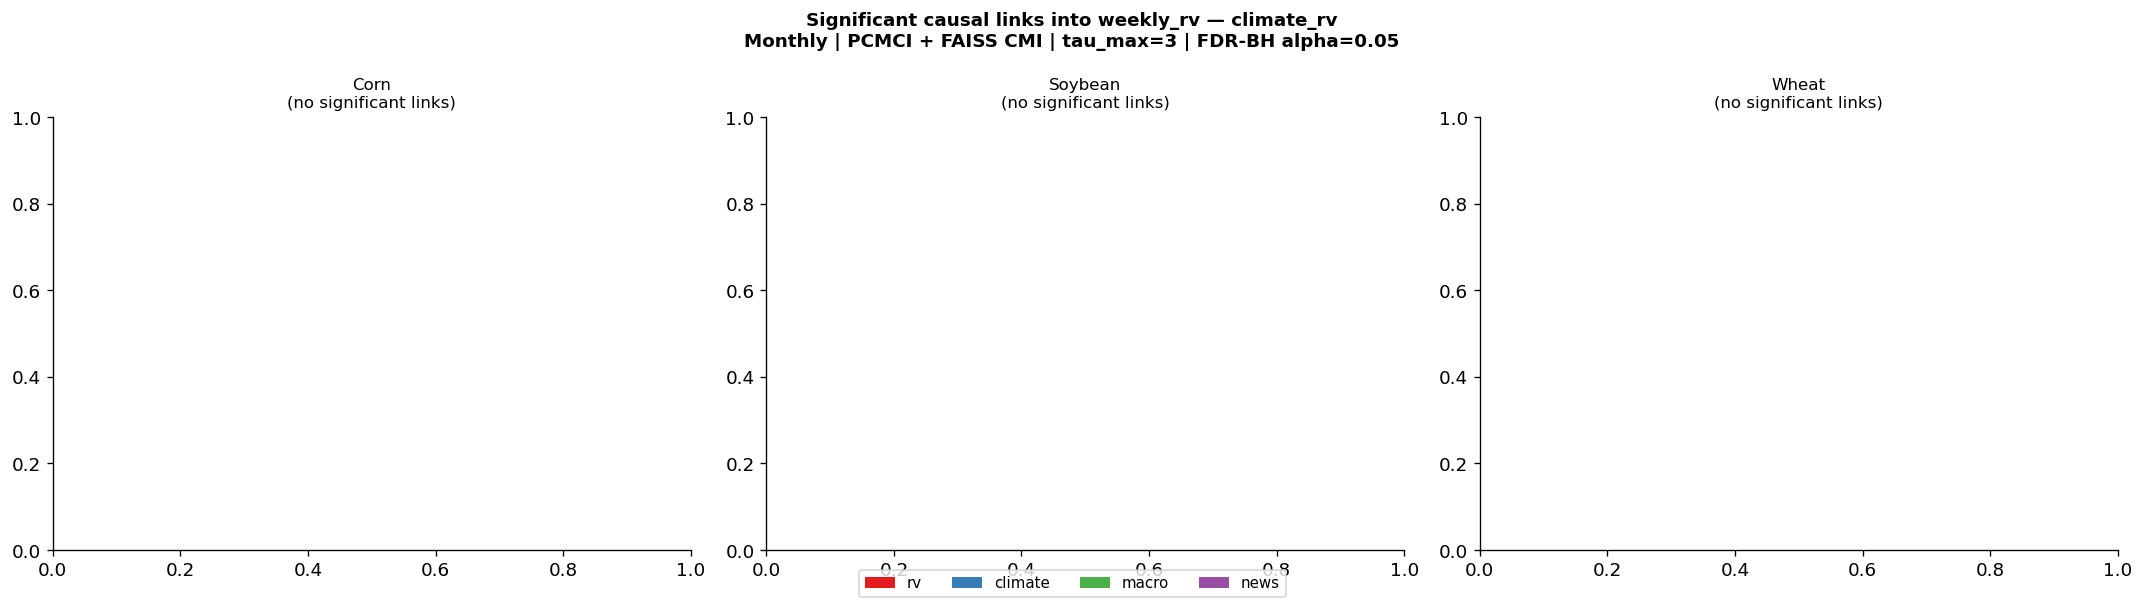

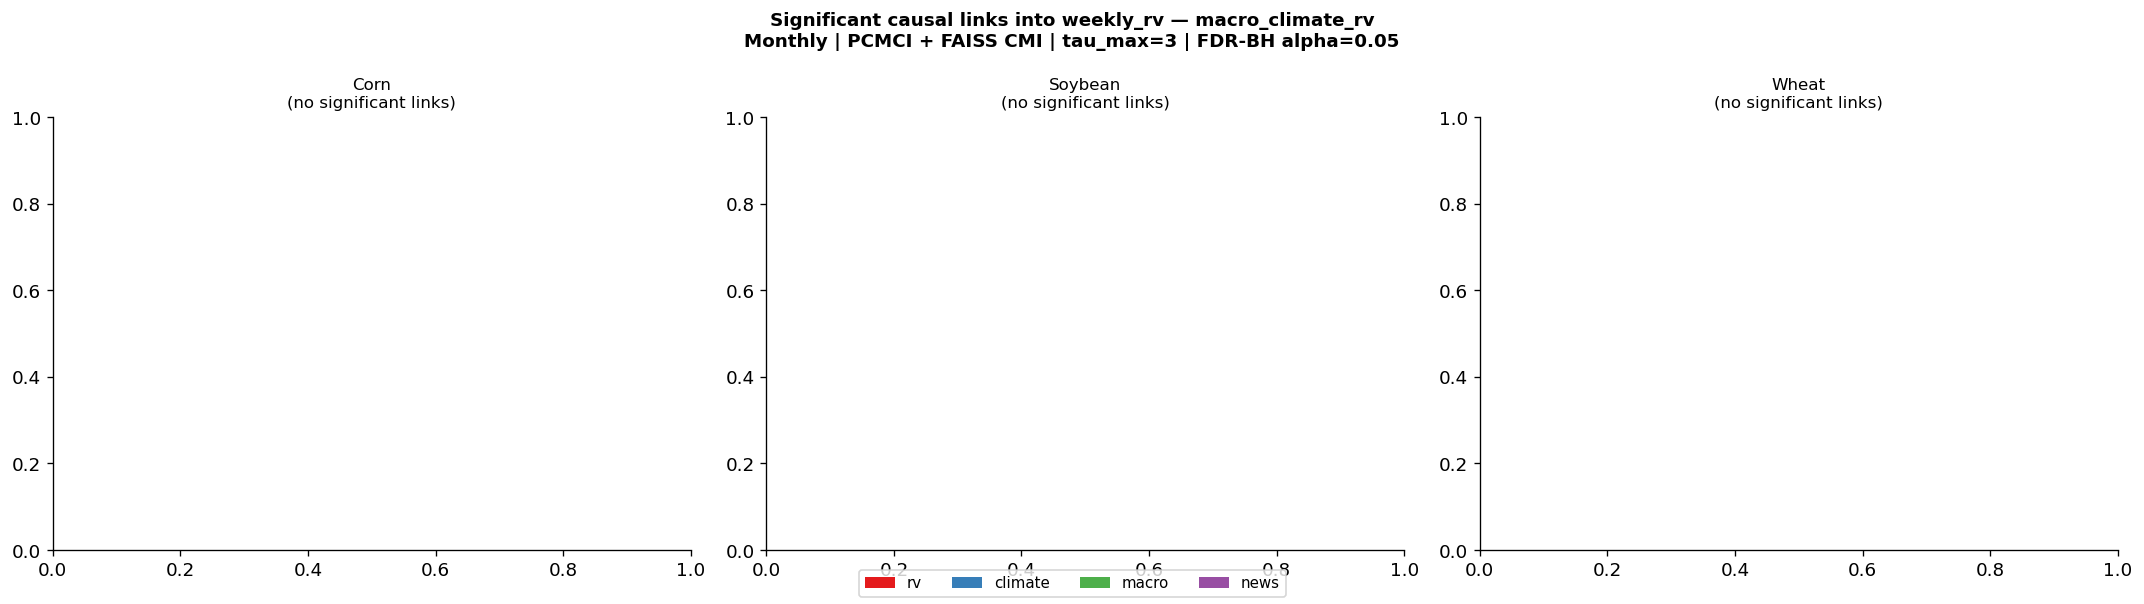

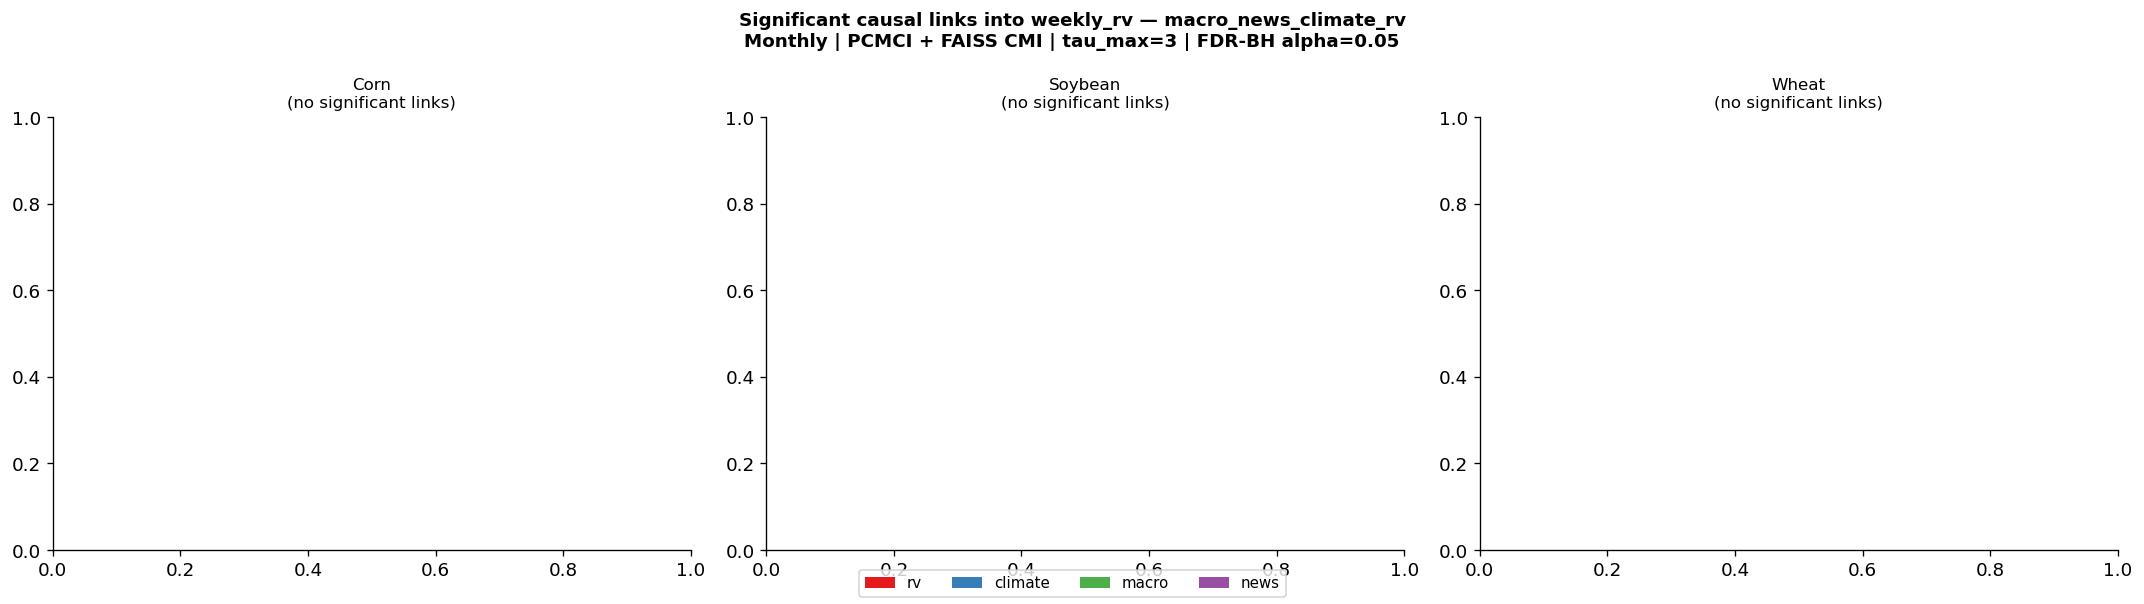

In [11]:
for fs_name in ['climate_rv', 'macro_climate_rv', 'macro_news_climate_rv']:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    for ax, crop in zip(axes, CROPS):
        links = extract_rv_links(all_results[crop][fs_name])
        if links.empty:
            ax.set_title(f'{crop.capitalize()}\n(no significant links)', fontsize=10)
            continue
        labels = [f"{r['cause']} (tau={r['lag']})" for _, r in links.iterrows()]
        vals   = links['val'].values
        colors = [GROUP_COLORS.get(group_of(r['cause']), '#888') for _, r in links.iterrows()]
        ax.barh(labels, vals, color=colors, alpha=0.85)
        ax.axvline(0, color='k', lw=0.8)
        ax.set_xlabel('MCI (CMI)')
        ax.set_title(f'{crop.capitalize()}', fontsize=11, fontweight='bold')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9)
    fig.suptitle(
        f'Significant causal links into weekly_rv — {fs_name}\n'
        f'{FREQUENCY.capitalize()} | PCMCI + FAISS CMI | tau_max={TAU_MAX} | FDR-BH alpha=0.05',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()


## 9. CMI vs ParCorr: Unique Links into `weekly_rv`

Links that FAISSCMI finds but ParCorr misses indicate **nonlinear or non-Gaussian** dependencies.
Links ParCorr finds that CMI misses indicate insufficient CMI power at k=5, T≈192 for that linear link.

In [12]:
print('Granger-causes of weekly_rv — FAISSCMI (climate_rv, tau <= 3):')
print(f'{"Crop":<12}  {"Cause":<35}  {"Lag":<5}  {"MCI (CMI)":<12}  {"q-val":<8}')
print('-' * 80)

for crop in CROPS:
    links = extract_rv_links(all_results[crop]['climate_rv'])
    if links.empty:
        print(f'{crop:<12}  (none)')
    else:
        for _, row in links.sort_values('q_val').iterrows():
            print(f"{crop:<12}  {row['cause']:<35}  "
                  f"tau={row['lag']:1d}  {row['val']:+.4f}        {row['q_val']:.4f}")

Granger-causes of weekly_rv — FAISSCMI (climate_rv, tau <= 3):
Crop          Cause                                Lag    MCI (CMI)     q-val   
--------------------------------------------------------------------------------
corn          (none)
soybean       (none)
wheat         (none)


## 10. Summary

**Preprocessing (identical to `eda_preprocessing.ipynb`):**
- Interpolate `pdsi`, `Broad_Dollar_index` | ffill `DJIA_Index`
- `pp.smooth(smooth_width=180, kernel='gaussian', residuals=True)` — 15-yr Gaussian detrend
- Phase-wise anomalization (`cycle_length=12`)
- `pp.trafo2normal` — rank-based Gaussianisation

**PCMCI + FAISSCMI config:**

| Parameter | Value | Reason |
|-----------|-------|--------|
| `tau_max` | 3 | Shuffle tests scale linearly with link count; tau=3 balances detection range and runtime |
| `pc_alpha` | 0.05 | Tighter skeleton — reduces shuffle-test overhead in MCI step |
| `k_neighbors` | 5 | Robust Kraskov choice for T ≈ 192 |
| `sig_samples` | 200 | Standard permutation precision; reduce to 50 for exploratory runs |
| `max_combinations` | 3 | Single conditioning set per MCI link — essential runtime control |
| `significance` | `shuffle_test` | Only valid option for CMI |
| `alpha_level` | 0.05 | Final FDR-BH threshold |

**Interpreting CMI values:**
- CMI ≥ 0 theoretically; small negative `val_matrix` entries are k-NN estimation noise for null links
- CMI finds, ParCorr misses → nonlinear / non-Gaussian dependency
- CMI finds, GPDC misses → dependency violates GPDC's additive-noise assumption (e.g., multiplicative)
- ParCorr finds, CMI misses → CMI had insufficient power at k=5, T=192 for that linear link

**Next steps:** Overlay CMI, ParCorr, and GPDC graphs to classify each link as linear-only, nonlinear-additive, or fully general.